# 03 — Analyse religiosity and outcomes

This is the **analysis** stage. Using the clean 50-state panel from notebook `02`, it tests the claim:

> More religious U.S. states have higher rates of gun violence, illiteracy, obesity, and incarceration.

Concretely, we ask whether `religiously_affiliated_pct` is associated with each of four outcomes:

| Outcome column | Direction the claim predicts |
|---|---|
| `firearm_death_rate_2024` | higher in more religious states |
| `adult_obesity_pct_2024` | higher in more religious states |
| `literacy_avg_score` | **lower** in more religious states (illiteracy ↑) |
| `imprisonment_rate_2023_all_ages` | higher in more religious states |

### How we test it (and how to read it)

We build the evidence up in layers, from simplest to most demanding:

1. **Missingness & descriptives** — know the data before modelling it.
2. **Correlations** (Pearson *and* Spearman) — is there an association at all, and is it robust to outliers?
3. **Scatter plots** — see the relationship and which states drive it.
4. **Simple OLS** — quantify the slope (change in outcome per +1 pp affiliation).
5. **Region-adjusted OLS** — the key test: does the association *survive* controlling for Census region, or is it just a North/South pattern?
6. **Top-vs-bottom comparison** — a plain-language summary for non-statisticians.

> **Important framing.** This is **ecological, descriptive** analysis of 50 states — not individuals, and not causal. A state-level correlation tells us nothing about whether religious *people* are more violent, less literate, etc. Religiosity is entangled with region, poverty, rurality, education, and policy; those confounders are the real caveat, and the region-adjusted models below are a first (crude) attempt to probe one of them.

## Setup and load the panel

Import the analysis stack (`scipy.stats` for correlations, `statsmodels` for OLS, `matplotlib` for figures), create the `reports/figures` and `reports/tables` output folders, and load the processed panel. The guard clauses fail clearly if notebook `02` has not been run yet (no processed file) or produced an empty table.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels.formula.api as smf

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

panel_path = PROCESSED_DIR / "state_religiosity_outcomes.csv"
if not panel_path.exists():
    raise FileNotFoundError(f"Missing processed file: {panel_path}. Run notebooks 01 and 02 first.")

panel = pd.read_csv(panel_path)
if panel.empty:
    raise ValueError("Processed panel is empty.")

panel.head()


,state,state_abbr,census_region,religiously_affiliated_pct,religiously_unaffiliated_pct,atheist_pct,agnostic_pct,nothing_in_particular_pct,firearm_death_rate_2024,firearm_homicide_rate_2024,...,uninsured_pct,snap_pct,pct_black,pct_hispanic,gun_ownership_pct_proxy,population_density,median_household_income,median_age,centroid_lat,centroid_lon
0,Alabama,AL,South,77.0,23.0,3.0,2.0,18.0,23.7,11.0,...,10.7,15.0,26.5,4.1,74.313023,95.768828,62212.0,39.6,32.759800,-86.830226
1,Alaska,AK,West,67.0,33.0,3.0,9.0,21.0,24.4,4.5,...,15.5,10.3,3.2,6.8,63.513514,1.293342,86631.0,36.5,63.726169,-149.836218
2,Arizona,AZ,West,70.0,30.0,3.0,5.0,22.0,16.9,4.4,...,12.2,12.5,4.3,30.9,61.543536,59.917491,77315.0,39.3,34.269321,-111.666668
3,Arkansas,AR,South,82.0,18.0,2.0,4.0,12.0,20.6,6.9,...,10.6,13.6,15.4,7.2,67.905405,57.276193,58700.0,38.9,34.891137,-92.442263
4,California,CA,West,67.0,33.0,6.0,7.0,20.0,7.0,3.1,...,10.5,9.3,5.8,38.8,38.040776,250.115887,95521.0,38.2,37.147771,-119.546925


## Missingness

Before any modelling, we check how complete each column is and save it to `reports/tables/missingness.csv`. This matters because every method below uses pairwise `dropna()`, so a column with missing values is analysed on a slightly smaller sample.

Here the panel is essentially complete: the only gap is **1 of 50** states in `adult_obesity_pct_2024` (2%). That single missing value is why the obesity analyses below run on **n = 49** while the others use **n = 50**.

In [2]:
missingness = panel.isna().sum().to_frame("missing_count")
missingness["missing_pct"] = missingness["missing_count"] / len(panel) * 100
missingness.to_csv(TABLES_DIR / "missingness.csv")
missingness

,missing_count,missing_pct
state,0,0.0
state_abbr,0,0.0
census_region,0,0.0
religiously_affiliated_pct,0,0.0
religiously_unaffiliated_pct,0,0.0
atheist_pct,0,0.0
agnostic_pct,0,0.0
nothing_in_particular_pct,0,0.0
firearm_death_rate_2024,0,0.0
firearm_homicide_rate_2024,0,0.0


## Descriptive statistics

A quick profile of the predictor and each outcome (count, mean, spread, range), saved to `reports/tables/descriptive_statistics.csv`. This grounds the later coefficients in real units.

A few things worth noting for interpretation:

- **Religious affiliation** ranges from ~52% to 85% across states (mean ≈ 70%, SD ≈ 6.8 pp) — there is real spread to correlate against.
- The outcomes are on **very different scales** (obesity ~25–41%, literacy ~252–279 points, imprisonment ~96–652 per 100k). That is why a raw OLS slope is large for imprisonment and small for firearm rate — the units differ, not necessarily the strength of association. Correlations (next) put them on a common −1…+1 scale.

In [3]:
analysis_columns = [
    "religiously_affiliated_pct",
    "firearm_death_rate_2024",
    "adult_obesity_pct_2024",
    "literacy_avg_score",
    "low_literacy_pct",
    "imprisonment_rate_2023_all_ages",
    "imprisonment_rate_2023_adult",
]
analysis_columns = [col for col in analysis_columns if col in panel.columns]

descriptive = panel[analysis_columns].describe().T
descriptive.to_csv(TABLES_DIR / "descriptive_statistics.csv")
descriptive

,count,mean,std,min,25%,50%,75%,max
religiously_affiliated_pct,50.0,70.020000,6.819809,52.0,66.25,70.00,74.000,85.0
firearm_death_rate_2024,50.0,14.508000,5.912451,3.7,11.65,14.05,18.275,28.0
adult_obesity_pct_2024,49.0,33.953061,3.707543,25.0,31.50,34.20,36.800,41.4
literacy_avg_score,50.0,266.630000,7.413068,251.5,260.55,267.20,272.700,278.9
imprisonment_rate_2023_all_ages,50.0,312.580000,134.110842,96.0,211.00,299.50,391.750,652.0
imprisonment_rate_2023_adult,50.0,400.620000,176.112544,118.0,275.25,385.00,501.500,847.0


## Pearson and Spearman correlations

This is the first real test of the claim. For each outcome we compute two correlations of `religiously_affiliated_pct` against it:

- **Pearson r** — strength of the *linear* association.
- **Spearman ρ** — strength of the *rank* (monotonic) association; less sensitive to a few outlier states.

Reporting both is a robustness check: if they agree, the relationship is not an artefact of one or two extreme states. Each comes with a p-value (the probability of seeing a correlation this large if there were truly none). Results are saved to `reports/tables/religiosity_correlations.csv`.

In [4]:
class CorrelationResult(NamedTuple):
    outcome: str
    n: int
    pearson_r: float
    pearson_p: float
    spearman_rho: float
    spearman_p: float


def compute_correlations(df: pd.DataFrame, x: str, outcomes: list[str]) -> pd.DataFrame:
    """Compute Pearson and Spearman correlations for one predictor and several outcomes."""
    rows: list[CorrelationResult] = []
    for outcome in outcomes:
        sample = df[[x, outcome]].dropna()
        if sample.shape[0] < 4:
            continue
        pearson = st.pearsonr(sample[x], sample[outcome])
        spearman = st.spearmanr(sample[x], sample[outcome])
        rows.append(CorrelationResult(
            outcome=outcome,
            n=sample.shape[0],
            pearson_r=float(pearson.statistic),
            pearson_p=float(pearson.pvalue),
            spearman_rho=float(spearman.statistic),
            spearman_p=float(spearman.pvalue),
        ))
    return pd.DataFrame(rows)

outcomes = [
    "firearm_death_rate_2024",
    "adult_obesity_pct_2024",
    "literacy_avg_score",
    "low_literacy_pct",
    "imprisonment_rate_2023_all_ages",
    "imprisonment_rate_2023_adult",
]
outcomes = [col for col in outcomes if col in panel.columns]

correlations = compute_correlations(panel, "religiously_affiliated_pct", outcomes)
correlations.to_csv(TABLES_DIR / "religiosity_correlations.csv", index=False)
correlations

,outcome,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,firearm_death_rate_2024,50,0.296539,0.036519,0.276615,0.051820
1,adult_obesity_pct_2024,49,0.543384,0.000055,0.566119,0.000022
2,literacy_avg_score,50,-0.513529,0.000137,-0.530534,0.000074
3,imprisonment_rate_2023_all_ages,50,0.480776,0.000409,0.422700,0.002228
4,imprisonment_rate_2023_adult,50,0.492737,0.000278,0.420223,0.002379


**Reading these results.** Every correlation points in the direction the claim predicts, and Pearson and Spearman broadly agree:

| Outcome | Pearson r | p | Interpretation |
|---|---|---|---|
| Firearm deaths | **+0.30** | 0.037 | weak positive — more religious states, somewhat more firearm deaths |
| Adult obesity | **+0.54** | <0.001 | moderate–strong positive (the strongest) |
| Literacy score | **−0.51** | <0.001 | moderate–strong negative — more religious states, lower literacy |
| Imprisonment (all ages) | **+0.48** | <0.001 | moderate positive |
| Imprisonment (adult) | **+0.49** | <0.001 | moderate positive |

So **at the bivariate level the claim is supported** for all four outcomes. The firearm association is the weakest (and its Spearman p ≈ 0.05 is borderline); obesity and literacy are the strongest. But correlation alone cannot separate religiosity from everything that travels with it geographically — which is exactly what the region-adjusted models test below.

## Scatter plots with fitted lines

Numbers can hide a lot, so we plot each outcome against religious affiliation, label every point with its state abbreviation (only 50 points, so labels are readable), and overlay a least-squares fit line to show the trend direction. Each figure is saved to `reports/figures/`.

What to look for: the **slope** (does the claim's direction hold?), the **scatter** around the line (how tight is the relationship?), and any **outlier states** pulling the fit. The state labels make it easy to spot, for example, whether high-religiosity Southern states cluster together — a visual hint of the regional confounding the next section formalises.

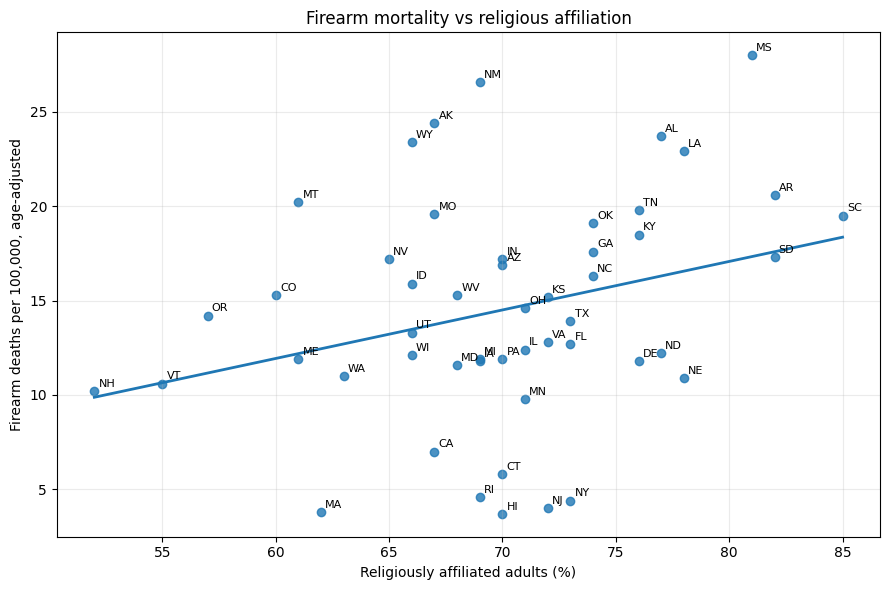

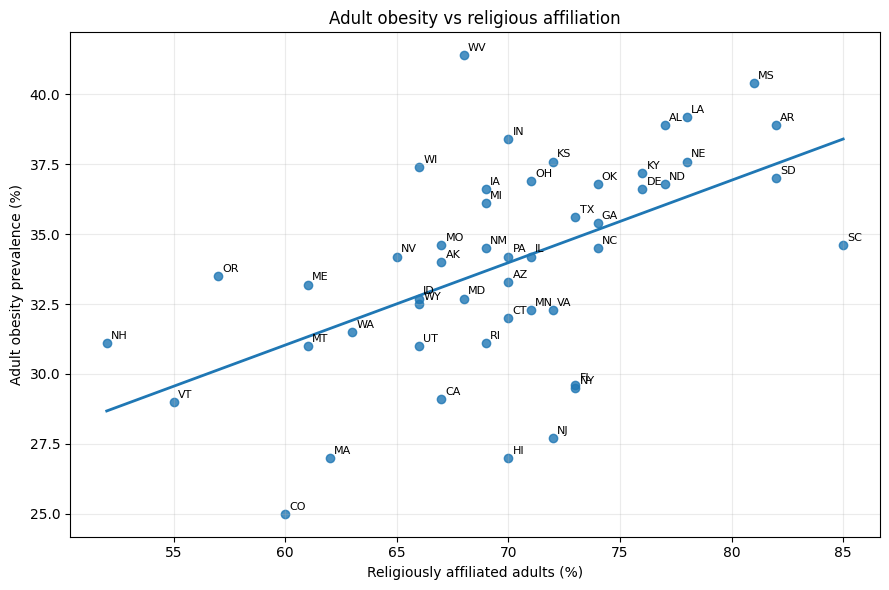

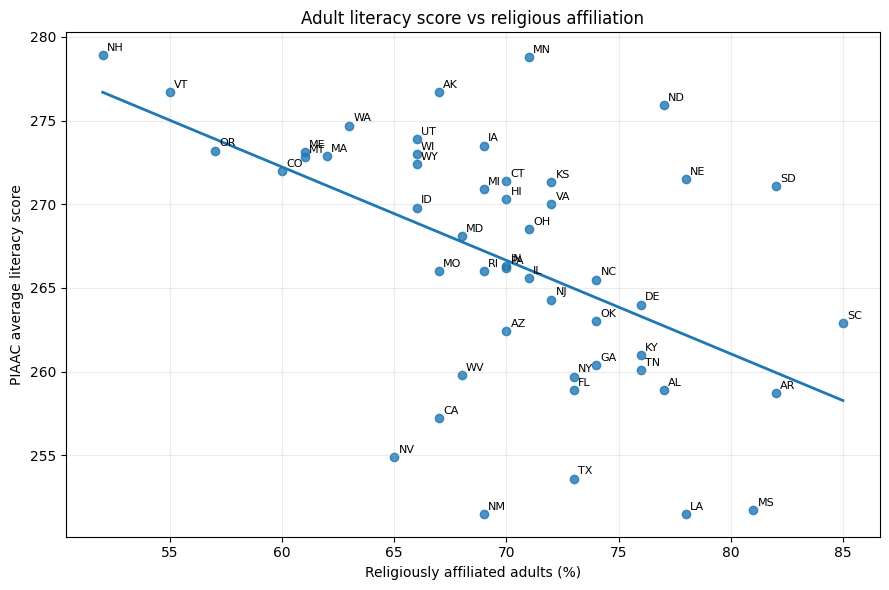

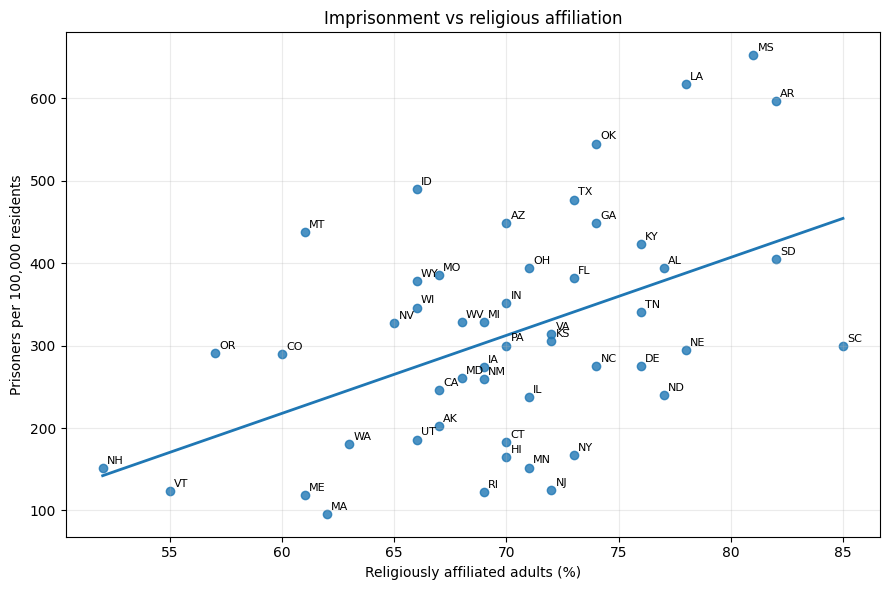

In [5]:
def plot_scatter_with_fit(df: pd.DataFrame, x: str, y: str, title: str, ylabel: str, filename: str) -> None:
    """Create a state-labelled scatter plot with a least-squares fitted line."""
    sample = df[["state_abbr", x, y]].dropna().copy()
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(sample[x], sample[y], alpha=0.8)

    # Simple fitted line.
    slope, intercept = np.polyfit(sample[x], sample[y], deg=1)
    x_grid = np.linspace(sample[x].min(), sample[x].max(), 100)
    ax.plot(x_grid, slope * x_grid + intercept, linewidth=2)

    # State labels are useful here because the dataset has only 50 rows.
    for _, row in sample.iterrows():
        ax.annotate(row["state_abbr"], (row[x], row[y]), xytext=(3, 3), textcoords="offset points", fontsize=8)

    ax.set_title(title)
    ax.set_xlabel("Religiously affiliated adults (%)")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=160)
    plt.show()

plot_specs = [
    ("firearm_death_rate_2024", "Firearm mortality vs religious affiliation", "Firearm deaths per 100,000, age-adjusted", "firearm_vs_religiosity.png"),
    ("adult_obesity_pct_2024", "Adult obesity vs religious affiliation", "Adult obesity prevalence (%)", "obesity_vs_religiosity.png"),
    ("literacy_avg_score", "Adult literacy score vs religious affiliation", "PIAAC average literacy score", "literacy_vs_religiosity.png"),
    ("imprisonment_rate_2023_all_ages", "Imprisonment vs religious affiliation", "Prisoners per 100,000 residents", "imprisonment_vs_religiosity.png"),
]

for y, title, ylabel, filename in plot_specs:
    if y in panel.columns:
        plot_scatter_with_fit(panel, "religiously_affiliated_pct", y, title, ylabel, filename)

## Simple OLS models

Correlation tells us *strength*; regression tells us *magnitude in real units*. Each model fits:

```text
outcome ~ religiously_affiliated_pct
```

so the coefficient is the estimated change in the outcome for **each additional percentage point** of religious affiliation. We use **HC3 robust standard errors**, which are appropriate when the spread of outcomes is uneven across states (heteroskedasticity), giving more trustworthy p-values on a small sample. `r_squared` is the share of cross-state variation in the outcome explained by religiosity alone. Results are saved to `reports/tables/simple_ols_models.csv`.

These models include **no controls** — they restate the bivariate relationship in interpretable units (e.g. each +1 pp of affiliation is associated with ~0.29 pp higher obesity and ~9.5 more prisoners per 100k).

In [6]:
def fit_simple_ols(df: pd.DataFrame, outcome: str) -> dict[str, float | str | int]:
    """Fit simple OLS with HC3 robust standard errors."""
    sample = df[["religiously_affiliated_pct", outcome]].dropna()
    model = smf.ols(f"{outcome} ~ religiously_affiliated_pct", data=sample).fit(cov_type="HC3")
    return {
        "outcome": outcome,
        "n": int(model.nobs),
        "coef_religiously_affiliated_pct": float(model.params["religiously_affiliated_pct"]),
        "se_hc3": float(model.bse["religiously_affiliated_pct"]),
        "p_value": float(model.pvalues["religiously_affiliated_pct"]),
        "r_squared": float(model.rsquared),
    }

simple_models = pd.DataFrame([fit_simple_ols(panel, outcome) for outcome in outcomes])
simple_models.to_csv(TABLES_DIR / "simple_ols_models.csv", index=False)
simple_models

,outcome,n,coef_religiously_affiliated_pct,se_hc3,p_value,r_squared
0,firearm_death_rate_2024,50,0.257085,0.097383,0.008292,0.087935
1,adult_obesity_pct_2024,49,0.294746,0.063340,0.000003,0.295266
2,literacy_avg_score,50,-0.558201,0.123770,0.000006,0.263712
3,imprisonment_rate_2023_all_ages,50,9.454414,2.733844,0.000544,0.231146
4,imprisonment_rate_2023_adult,50,12.724280,3.563645,0.000356,0.242790


## Region-adjusted OLS models

This is the **most important test in the notebook.** U.S. religiosity is strongly regional — the South is both the most religious region and, independently, has higher firearm mortality, obesity, and incarceration for many historical, economic, and policy reasons. So a raw religiosity–outcome correlation might simply be *"the South looks different"* in disguise.

To probe this, we add Census region as a categorical control:

```text
outcome ~ religiously_affiliated_pct + C(census_region)
```

This compares states **within the same region**. The question becomes: once we hold region constant, does religious affiliation *still* predict the outcome? If the coefficient shrinks toward zero and loses significance, the bivariate association was largely a regional pattern. If it survives, the relationship is more robust. Results are saved to `reports/tables/region_adjusted_ols_models.csv`.

> Caveat: region is a *crude* proxy for the real confounders (poverty, education, urbanisation, race, gun laws). Surviving region adjustment is necessary but not sufficient evidence; failing it is a strong signal the association is not specifically about religiosity.

In [7]:
def fit_region_adjusted_ols(df: pd.DataFrame, outcome: str) -> dict[str, float | str | int]:
    """Fit OLS adjusted for Census region with HC3 robust standard errors."""
    sample = df[["religiously_affiliated_pct", "census_region", outcome]].dropna()
    model = smf.ols(f"{outcome} ~ religiously_affiliated_pct + C(census_region)", data=sample).fit(cov_type="HC3")
    return {
        "outcome": outcome,
        "n": int(model.nobs),
        "coef_religiously_affiliated_pct": float(model.params["religiously_affiliated_pct"]),
        "se_hc3": float(model.bse["religiously_affiliated_pct"]),
        "p_value": float(model.pvalues["religiously_affiliated_pct"]),
        "r_squared": float(model.rsquared),
    }

region_models = pd.DataFrame([fit_region_adjusted_ols(panel, outcome) for outcome in outcomes])
region_models.to_csv(TABLES_DIR / "region_adjusted_ols_models.csv", index=False)
region_models

,outcome,n,coef_religiously_affiliated_pct,se_hc3,p_value,r_squared
0,firearm_death_rate_2024,50,0.078722,0.138469,0.569685,0.386375
1,adult_obesity_pct_2024,49,0.087148,0.084756,0.303848,0.515489
2,literacy_avg_score,50,-0.502737,0.149406,0.000766,0.466822
3,imprisonment_rate_2023_all_ages,50,3.845168,2.889866,0.183331,0.467051
4,imprisonment_rate_2023_adult,50,5.523097,3.791771,0.145227,0.472825


**This is where the story changes.** Comparing the religiosity coefficient before and after adjusting for region:

| Outcome | Simple coef (p) | Region-adjusted coef (p) | Verdict |
|---|---|---|---|
| Firearm deaths | 0.257 (0.008) | 0.079 (**0.57**) | **vanishes** — explained by region |
| Adult obesity | 0.295 (<0.001) | 0.087 (**0.30**) | **vanishes** — explained by region |
| Imprisonment (all ages) | 9.45 (<0.001) | 3.85 (**0.18**) | **vanishes** — explained by region |
| Imprisonment (adult) | 12.72 (<0.001) | 5.52 (**0.15**) | **vanishes** — explained by region |
| **Literacy score** | −0.558 (<0.001) | **−0.503 (0.0008)** | **survives** — robust to region |

For firearm deaths, obesity, and imprisonment, the religiosity coefficient collapses by ~65–70% and loses all statistical significance once region is included. In other words, those three associations are mostly **"the South effect"** — religiosity is a marker for region, not an independent predictor here.

**Literacy is the exception.** Its coefficient barely moves (−0.56 → −0.50) and stays highly significant. The negative religiosity–literacy association holds *even when comparing states within the same region* — the one relationship that is not simply regional in this dataset.

## Top-versus-bottom comparison

Finally, a non-technical summary: split the states into the **10 most** and **10 least** religiously affiliated, and compare their average outcomes. This is the kind of contrast that motivates the original claim, and it makes the raw gaps concrete. Saved to `reports/tables/top_bottom_religiosity_comparison.csv`.

In [8]:
def top_bottom_summary(df: pd.DataFrame, group_size: int = 10) -> pd.DataFrame:
    """Compare the highest and lowest states by religious affiliation."""
    sorted_df = df.sort_values("religiously_affiliated_pct")
    least = sorted_df.head(group_size).assign(group=f"{group_size} least religiously affiliated")
    most = sorted_df.tail(group_size).assign(group=f"{group_size} most religiously affiliated")
    comparison = pd.concat([least, most], axis=0)
    numeric_cols = comparison.select_dtypes(include="number").columns.tolist()
    return comparison.groupby("group")[numeric_cols].mean().T

top_bottom = top_bottom_summary(panel)
top_bottom.to_csv(TABLES_DIR / "top_bottom_religiosity_comparison.csv")
top_bottom

group,10 least religiously affiliated,10 most religiously affiliated
religiously_affiliated_pct,60.200000,79.200000
religiously_unaffiliated_pct,39.800000,20.800000
atheist_pct,7.200000,2.900000
agnostic_pct,9.300000,3.400000
nothing_in_particular_pct,23.300000,14.500000
firearm_death_rate_2024,12.770000,18.670000
firearm_homicide_rate_2024,2.380000,7.370000
firearm_suicide_rate_2024,10.790000,10.700000
adult_obesity_pct_2024,30.650000,37.777778
literacy_avg_score,272.310000,262.630000


**The gaps are large and all point the claim's way.** On every outcome, the 10 most religious states fare worse than the 10 least religious:

| Average of… | 10 least religious | 10 most religious | Gap |
|---|---|---|---|
| Religious affiliation | 60.2% | 79.2% | — |
| Firearm deaths /100k | 12.8 | 18.7 | **+46%** |
| Adult obesity | 30.7% | 37.8% | **+7.1 pp** |
| Literacy score | 272.3 | 262.6 | **−9.7 pts** |
| Imprisonment /100k | 220 | 411 | **+87%** |

The headline contrast is striking — the most religious states imprison nearly **twice** as many people per capita and have ~46% higher firearm mortality. But keep the region-adjusted models in mind: most of these gaps shrink to non-significance once you compare like-for-like within regions. The vivid top-vs-bottom split and the careful regression tell *different halves of the same story* — which the conclusion ties together.

# Part 2 — Deeper analysis

Part 1 established the headline associations. The panel now also carries **candidate confounders** (poverty, education, unemployment, uninsured rate, SNAP, race composition) and a second literacy-style outcome (**numeracy**). This part uses them to push much harder on the central question: *is religiosity associated with these outcomes on its own, or only because it travels with region and socioeconomics?*

It adds: variable distributions, a full correlation heatmap, regional structure, region-coloured scatters, religiosity-vs-confounder checks, **covariate-adjusted regressions**, a model-comparison forest plot, partial correlations, multiple-comparison control, bootstrap uncertainty, and influence diagnostics.

In [9]:
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

PREDICTOR = "religiously_affiliated_pct"
EXT_OUTCOMES = [c for c in [
    "firearm_death_rate_2024", "firearm_homicide_rate_2024", "firearm_suicide_rate_2024",
    "adult_obesity_pct_2024", "literacy_avg_score", "numeracy_avg_score",
    "imprisonment_rate_2023_all_ages",
] if c in panel.columns]
# General confounders (note: gun ownership is handled separately in the firearm section,
# since for firearm outcomes it is a mechanism, not just a confounder).
CONTROLS = [c for c in [
    "poverty_pct", "less_than_hs_pct", "unemployment_pct",
    "uninsured_pct", "pct_black", "pct_hispanic", "population_density",
    "median_household_income", "median_age",
] if c in panel.columns]

REGION_ORDER = ["Northeast", "Midwest", "South", "West"]
REGION_COLORS = {"Northeast": "#1f77b4", "Midwest": "#2ca02c", "South": "#d62728", "West": "#9467bd"}
LABELS = {
    "religiously_affiliated_pct": "Religious affiliation (%)",
    "firearm_death_rate_2024": "Firearm deaths /100k",
    "firearm_homicide_rate_2024": "Firearm homicide /100k",
    "firearm_suicide_rate_2024": "Firearm suicide /100k",
    "adult_obesity_pct_2024": "Adult obesity (%)",
    "literacy_avg_score": "Literacy score",
    "numeracy_avg_score": "Numeracy score",
    "imprisonment_rate_2023_all_ages": "Imprisonment /100k",
    "imprisonment_rate_2023_adult": "Imprisonment adult /100k",
    "poverty_pct": "Poverty (%)", "less_than_hs_pct": "< High school (%)",
    "unemployment_pct": "Unemployment (%)", "uninsured_pct": "Uninsured (%)",
    "snap_pct": "SNAP (%)", "pct_black": "% Black", "pct_hispanic": "% Hispanic",
    "gun_ownership_pct_proxy": "Gun ownership (FS/S proxy, %)", "population_density": "Pop. density (/sq mi)",
    "median_household_income": "Median income ($)", "median_age": "Median age (yrs)",
}
print("Outcomes:", EXT_OUTCOMES)
print("Controls:", CONTROLS)

Outcomes: ['firearm_death_rate_2024', 'firearm_homicide_rate_2024', 'firearm_suicide_rate_2024', 'adult_obesity_pct_2024', 'literacy_avg_score', 'numeracy_avg_score', 'imprisonment_rate_2023_all_ages']
Controls: ['poverty_pct', 'less_than_hs_pct', 'unemployment_pct', 'uninsured_pct', 'pct_black', 'pct_hispanic', 'population_density', 'median_household_income', 'median_age']


## Distributions

Before correlating, look at each variable's shape: is it roughly symmetric, skewed, or driven by a couple of extreme states? The red line marks the mean, the dashed line the median; a gap between them signals skew.

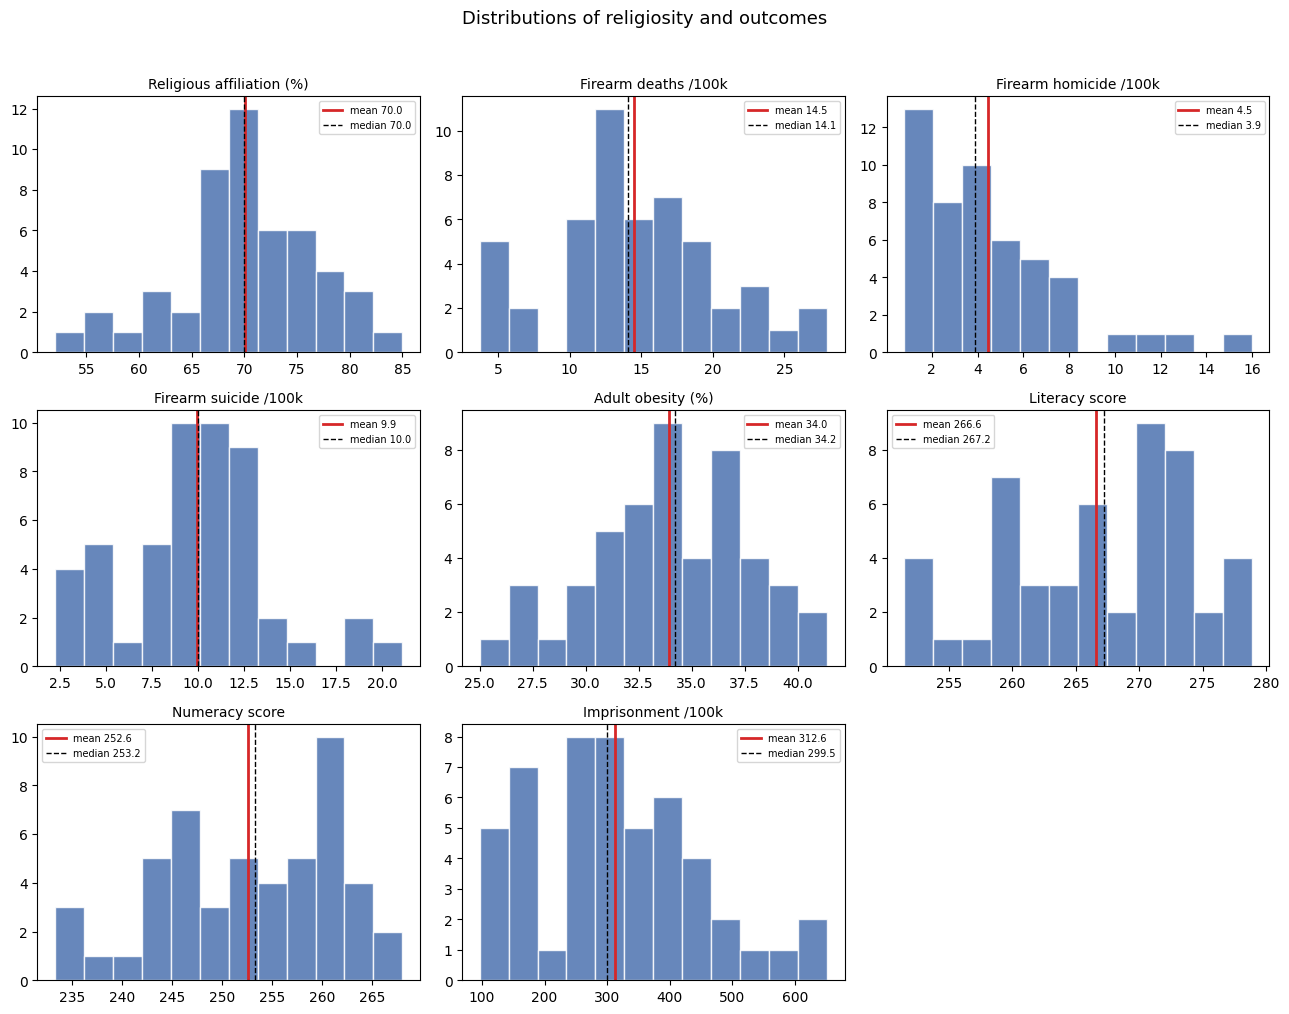

In [10]:
dist_vars = [PREDICTOR] + EXT_OUTCOMES
ncol = 3
nrow = int(np.ceil(len(dist_vars) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.3 * nrow))
axes = np.array(axes).flatten()
for ax, v in zip(axes, dist_vars):
    data = panel[v].dropna()
    ax.hist(data, bins=12, color="#4c72b0", alpha=0.85, edgecolor="white")
    ax.axvline(data.mean(), color="#d62728", lw=2, label=f"mean {data.mean():.1f}")
    ax.axvline(data.median(), color="black", lw=1, ls="--", label=f"median {data.median():.1f}")
    ax.set_title(LABELS.get(v, v), fontsize=10)
    ax.legend(fontsize=7)
for ax in axes[len(dist_vars):]:
    ax.axis("off")
fig.suptitle("Distributions of religiosity and outcomes", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Correlation heatmap

A single picture of how *everything* moves together — religiosity, the outcomes, and the confounders. Watch the religiosity row: if its correlations with the outcomes look similar to the confounders' correlations with those same outcomes, that is a strong hint the religiosity signal is shared, not unique.

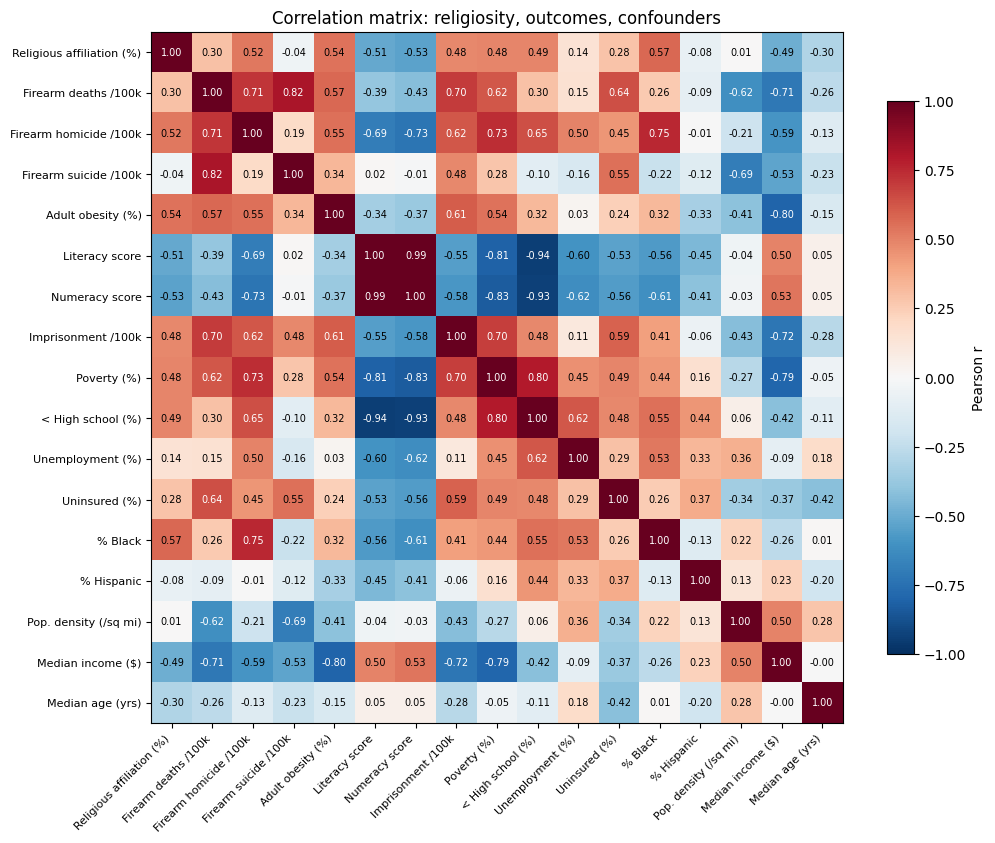

,religiously_affiliated_pct,firearm_death_rate_2024,firearm_homicide_rate_2024,firearm_suicide_rate_2024,adult_obesity_pct_2024,literacy_avg_score,numeracy_avg_score,imprisonment_rate_2023_all_ages,poverty_pct,less_than_hs_pct,unemployment_pct,uninsured_pct,pct_black,pct_hispanic,population_density,median_household_income,median_age
religiously_affiliated_pct,1.00,0.30,0.52,-0.04,0.54,-0.51,-0.53,0.48,0.48,0.49,0.14,0.28,0.57,-0.08,0.01,-0.49,-0.30
firearm_death_rate_2024,0.30,1.00,0.71,0.82,0.57,-0.39,-0.43,0.70,0.62,0.30,0.15,0.64,0.26,-0.09,-0.62,-0.71,-0.26
firearm_homicide_rate_2024,0.52,0.71,1.00,0.19,0.55,-0.69,-0.73,0.62,0.73,0.65,0.50,0.45,0.75,-0.01,-0.21,-0.59,-0.13
firearm_suicide_rate_2024,-0.04,0.82,0.19,1.00,0.34,0.02,-0.01,0.48,0.28,-0.10,-0.16,0.55,-0.22,-0.12,-0.69,-0.53,-0.23
adult_obesity_pct_2024,0.54,0.57,0.55,0.34,1.00,-0.34,-0.37,0.61,0.54,0.32,0.03,0.24,0.32,-0.33,-0.41,-0.80,-0.15
literacy_avg_score,-0.51,-0.39,-0.69,0.02,-0.34,1.00,0.99,-0.55,-0.81,-0.94,-0.60,-0.53,-0.56,-0.45,-0.04,0.50,0.05
numeracy_avg_score,-0.53,-0.43,-0.73,-0.01,-0.37,0.99,1.00,-0.58,-0.83,-0.93,-0.62,-0.56,-0.61,-0.41,-0.03,0.53,0.05
imprisonment_rate_2023_all_ages,0.48,0.70,0.62,0.48,0.61,-0.55,-0.58,1.00,0.70,0.48,0.11,0.59,0.41,-0.06,-0.43,-0.72,-0.28
poverty_pct,0.48,0.62,0.73,0.28,0.54,-0.81,-0.83,0.70,1.00,0.80,0.45,0.49,0.44,0.16,-0.27,-0.79,-0.05
less_than_hs_pct,0.49,0.30,0.65,-0.10,0.32,-0.94,-0.93,0.48,0.80,1.00,0.62,0.48,0.55,0.44,0.06,-0.42,-0.11


In [11]:
heat_vars = [PREDICTOR] + EXT_OUTCOMES + CONTROLS
corr = panel[heat_vars].corr(method="pearson")
fig, ax = plt.subplots(figsize=(10.5, 8.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(heat_vars)))
ax.set_xticklabels([LABELS.get(v, v) for v in heat_vars], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(heat_vars)))
ax.set_yticklabels([LABELS.get(v, v) for v in heat_vars], fontsize=8)
for i in range(len(heat_vars)):
    for j in range(len(heat_vars)):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(val) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Correlation matrix: religiosity, outcomes, confounders")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
corr.round(2)

## Structure by Census region

The confounding hypothesis is regional, so plot each variable by region. If the most religious region (the South) also sits high on the bad outcomes and high on poverty/low education, then region and religiosity are hard to separate — which is exactly what the adjusted models below have to contend with.

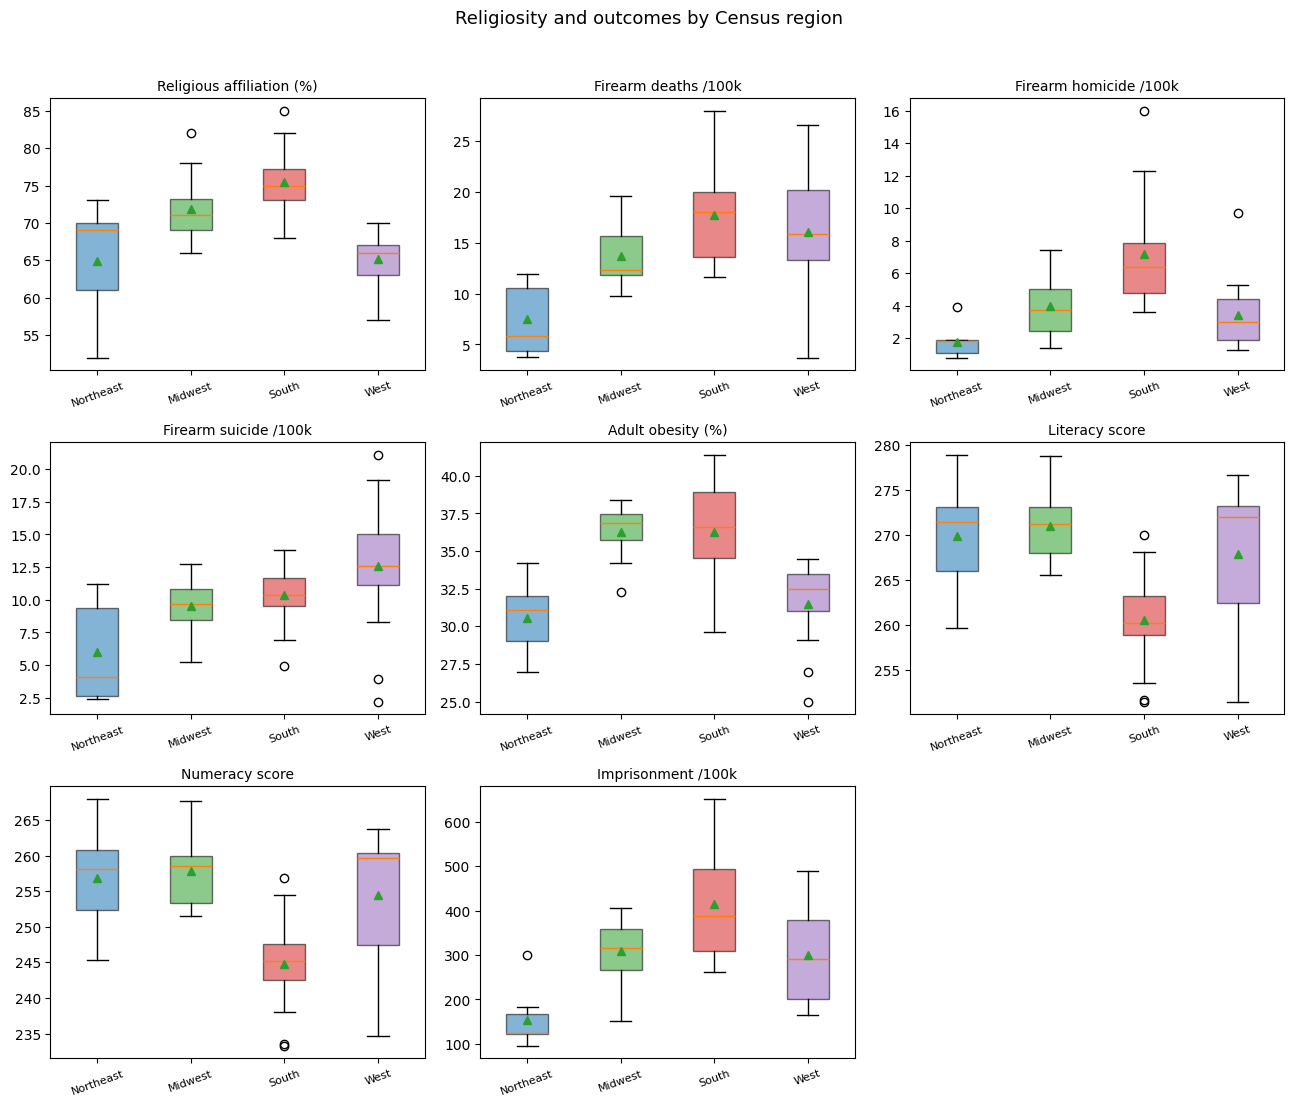

In [12]:
box_vars = [PREDICTOR] + EXT_OUTCOMES
ncol = 3
nrow = int(np.ceil(len(box_vars) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.6 * nrow))
axes = np.array(axes).flatten()
for ax, v in zip(axes, box_vars):
    groups = [panel.loc[panel["census_region"] == r, v].dropna().values for r in REGION_ORDER]
    bp = ax.boxplot(groups, tick_labels=REGION_ORDER, patch_artist=True, showmeans=True)
    for patch, r in zip(bp["boxes"], REGION_ORDER):
        patch.set_facecolor(REGION_COLORS[r])
        patch.set_alpha(0.55)
    ax.set_title(LABELS.get(v, v), fontsize=10)
    ax.tick_params(axis="x", labelrotation=20, labelsize=8)
for ax in axes[len(box_vars):]:
    ax.axis("off")
fig.suptitle("Religiosity and outcomes by Census region", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "by_region_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## Scatters coloured by region

The same religiosity-vs-outcome scatters as Part 1, but each state is coloured by region. If the overall downward/upward slope is mostly produced by the regional clusters sitting in different corners — rather than a trend *within* each colour — then the relationship is largely between-region.

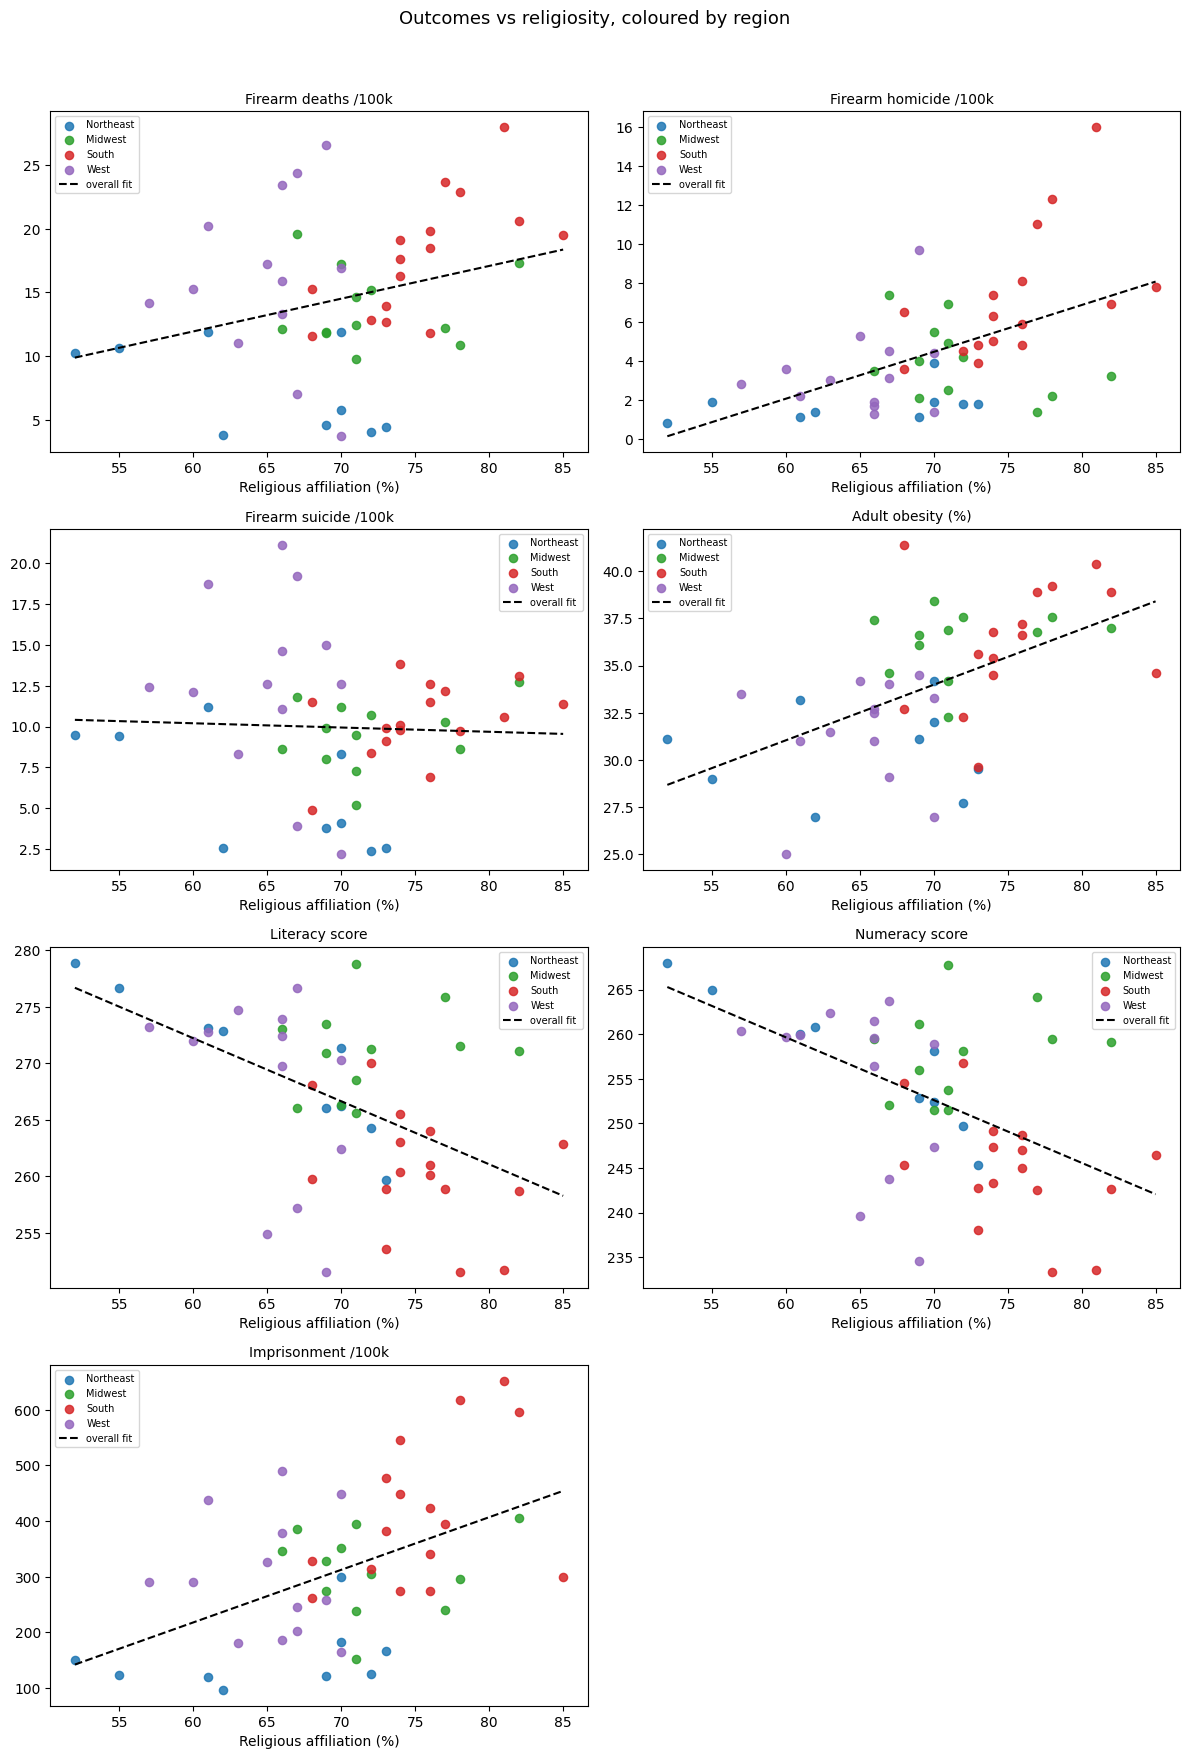

In [13]:
sc_vars = EXT_OUTCOMES
ncol = 2
nrow = int(np.ceil(len(sc_vars) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 4.3 * nrow))
axes = np.array(axes).flatten()
for ax, v in zip(axes, sc_vars):
    sub = panel[[PREDICTOR, v, "census_region", "state_abbr"]].dropna()
    for r in REGION_ORDER:
        rr = sub[sub["census_region"] == r]
        ax.scatter(rr[PREDICTOR], rr[v], color=REGION_COLORS[r], label=r, alpha=0.85, s=35)
    slope, intercept = np.polyfit(sub[PREDICTOR], sub[v], 1)
    xg = np.linspace(sub[PREDICTOR].min(), sub[PREDICTOR].max(), 50)
    ax.plot(xg, slope * xg + intercept, color="black", lw=1.5, ls="--", label="overall fit")
    ax.set_title(LABELS.get(v, v), fontsize=10)
    ax.set_xlabel("Religious affiliation (%)")
    ax.legend(fontsize=7)
for ax in axes[len(sc_vars):]:
    ax.axis("off")
fig.suptitle("Outcomes vs religiosity, coloured by region", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "region_colored_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## Is religiosity entangled with the confounders?

Adjusting for a confounder only changes the answer if religiosity is actually correlated with it. So here we correlate religious affiliation directly with each candidate confounder. Strong correlations here are the *mechanism* by which the adjusted models can differ from the raw ones.

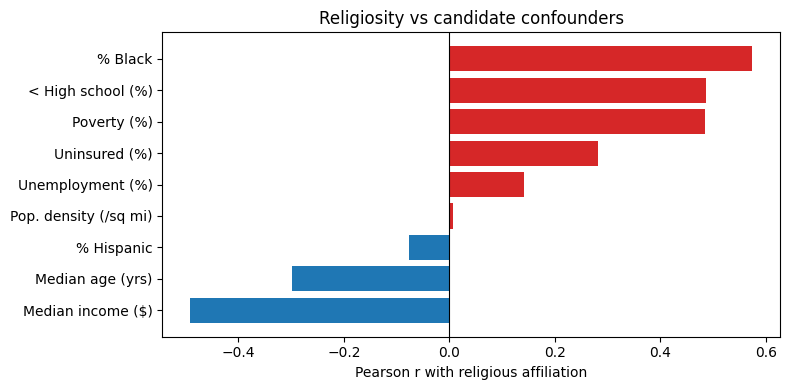

,confounder,pearson_r,p_value,n
7,median_household_income,-0.491,0.000,50
8,median_age,-0.299,0.035,50
5,pct_hispanic,-0.076,0.600,50
6,population_density,0.008,0.958,50
2,unemployment_pct,0.141,0.328,50
3,uninsured_pct,0.282,0.047,50
0,poverty_pct,0.485,0.000,50
1,less_than_hs_pct,0.486,0.000,50
4,pct_black,0.573,0.000,50


In [14]:
rows = []
for c in CONTROLS:
    sub = panel[[PREDICTOR, c]].dropna()
    r, pv = st.pearsonr(sub[PREDICTOR], sub[c])
    rows.append({"confounder": c, "pearson_r": r, "p_value": pv, "n": len(sub)})
conf = pd.DataFrame(rows).sort_values("pearson_r")
conf.to_csv(TABLES_DIR / "religiosity_vs_confounders.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d62728" if x > 0 else "#1f77b4" for x in conf["pearson_r"]]
ax.barh([LABELS.get(v, v) for v in conf["confounder"]], conf["pearson_r"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Pearson r with religious affiliation")
ax.set_title("Religiosity vs candidate confounders")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "religiosity_vs_confounders.png", dpi=150, bbox_inches="tight")
plt.show()
conf.round(3)

## Covariate-adjusted regressions (the real test)

Part 1 adjusted for region only. Now we fit four specifications for every outcome and track the religiosity coefficient across them:

1. **simple** — `outcome ~ religiosity`
2. **+region** — add Census region
3. **+covariates** — add poverty, education, unemployment, uninsured, % Black, % Hispanic
4. **+region & covariates** — everything together

We report both the raw coefficient and the **standardised β** (effect in SD units, so outcomes on different scales are comparable). If religiosity's coefficient collapses toward zero and loses significance as controls are added, the raw association was confounded; if it holds, it is robust.

In [15]:
def fit_spec(outcome, spec):
    cols = [PREDICTOR, outcome]
    if spec in ("region", "region+cov"):
        cols = cols + ["census_region"]
    if spec in ("cov", "region+cov"):
        cols = cols + CONTROLS
    sub = panel[cols].dropna()
    rhs = PREDICTOR
    if spec in ("region", "region+cov"):
        rhs += " + C(census_region)"
    if spec in ("cov", "region+cov"):
        rhs += " + " + " + ".join(CONTROLS)
    m = smf.ols(f"{outcome} ~ {rhs}", data=sub).fit(cov_type="HC3")
    b = float(m.params[PREDICTOR]); se = float(m.bse[PREDICTOR]); pv = float(m.pvalues[PREDICTOR])
    sx = sub[PREDICTOR].std(); sy = sub[outcome].std()
    return {
        "outcome": outcome, "spec": spec, "n": int(m.nobs),
        "coef": b, "se": se, "p_value": pv,
        "std_beta": b * sx / sy, "std_beta_se": se * sx / sy,
        "r_squared": float(m.rsquared),
    }

specs = ["simple", "region", "cov", "region+cov"]
modcmp = pd.DataFrame([fit_spec(o, s) for o in EXT_OUTCOMES for s in specs])
modcmp.to_csv(TABLES_DIR / "model_comparison.csv", index=False)
modcmp.round(4)

,outcome,spec,n,coef,se,p_value,std_beta,std_beta_se,r_squared
0,firearm_death_rate_2024,simple,50,0.2571,0.0974,0.0083,0.2965,0.1123,0.0879
1,firearm_death_rate_2024,region,50,0.0787,0.1385,0.5697,0.0908,0.1597,0.3864
2,firearm_death_rate_2024,cov,50,-0.0986,0.1140,0.3872,-0.1137,0.1315,0.8019
3,firearm_death_rate_2024,region+cov,50,-0.0863,0.1602,0.5900,-0.0996,0.1848,0.8372
4,firearm_homicide_rate_2024,simple,50,0.2403,0.0661,0.0003,0.5250,0.1444,0.2756
5,firearm_homicide_rate_2024,region,50,0.1097,0.0661,0.0971,0.2397,0.1445,0.4502
6,firearm_homicide_rate_2024,cov,50,-0.0372,0.0515,0.4699,-0.0813,0.1126,0.8436
7,firearm_homicide_rate_2024,region+cov,50,-0.0390,0.0607,0.5211,-0.0851,0.1327,0.8456
8,firearm_suicide_rate_2024,simple,50,-0.0260,0.0679,0.7019,-0.0430,0.1123,0.0018
9,firearm_suicide_rate_2024,region,50,-0.0803,0.1036,0.4386,-0.1327,0.1714,0.2945


## Model-comparison forest plot

The table above, made readable. Each panel is one outcome; each row is a specification, showing the **standardised religiosity coefficient** with its 95% confidence interval. Red = still significant (p<0.05), grey = not. Reading top-to-bottom shows how much of each raw association is explained away by controls.

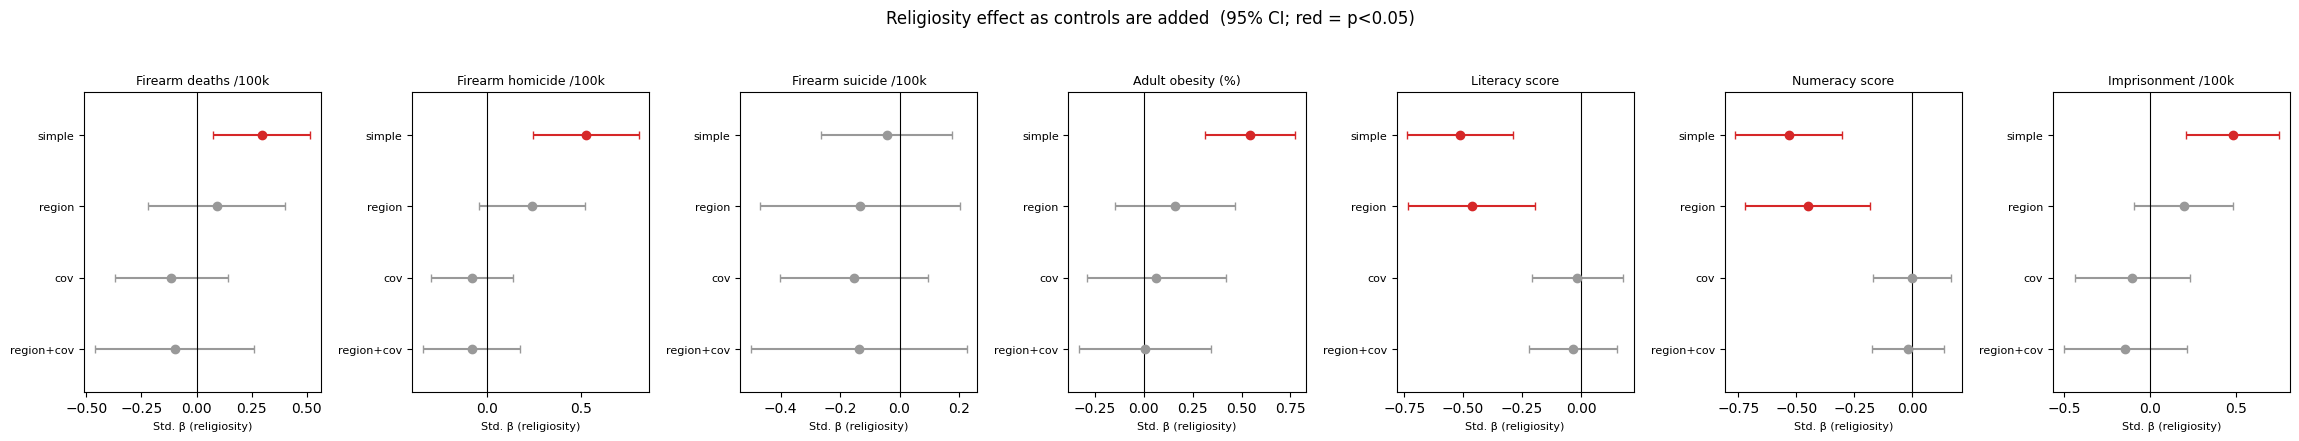

In [16]:
spec_y = {"simple": 3, "region": 2, "cov": 1, "region+cov": 0}
fig, axes = plt.subplots(1, len(EXT_OUTCOMES), figsize=(3.3 * len(EXT_OUTCOMES), 4.2))
axes = np.atleast_1d(axes)
for ax, o in zip(axes, EXT_OUTCOMES):
    sub = modcmp[modcmp["outcome"] == o]
    for _, r in sub.iterrows():
        y = spec_y[r["spec"]]
        color = "#d62728" if r["p_value"] < 0.05 else "#999999"
        ax.errorbar(r["std_beta"], y, xerr=1.96 * r["std_beta_se"], fmt="o",
                    color=color, capsize=3, lw=1.5)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_yticks(list(spec_y.values()))
    ax.set_yticklabels(list(spec_y.keys()), fontsize=8)
    ax.set_ylim(-0.6, 3.6)
    ax.set_title(LABELS.get(o, o), fontsize=9)
    ax.set_xlabel("Std. β (religiosity)", fontsize=8)
fig.suptitle("Religiosity effect as controls are added  (95% CI; red = p<0.05)", y=1.04, fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_comparison_forest.png", dpi=150, bbox_inches="tight")
plt.show()

## Partial correlations

A complementary view to the regressions. We regress poverty, education, unemployment, uninsured rate, and race composition out of **both** religiosity and the outcome, then correlate the residuals. The partial correlation is the religiosity–outcome association that remains after the confounders are removed from both sides. The residual scatters visualise it.

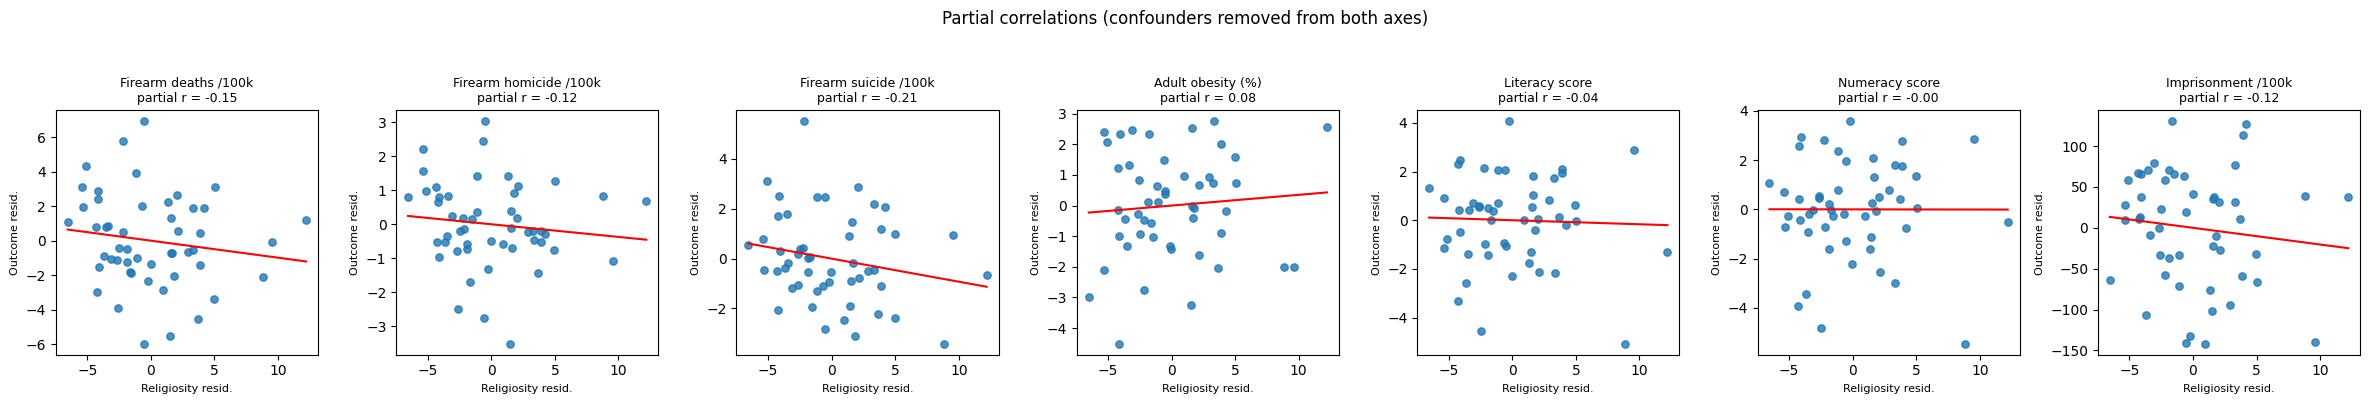

,outcome,raw_r,raw_p,partial_r,partial_p,n
0,firearm_death_rate_2024,0.2965,0.0365,-0.1488,0.3025,50
1,firearm_homicide_rate_2024,0.5250,0.0001,-0.1203,0.4054,50
2,firearm_suicide_rate_2024,-0.0430,0.7669,-0.2073,0.1486,50
3,adult_obesity_pct_2024,0.5434,0.0001,0.0827,0.5720,49
4,literacy_avg_score,-0.5135,0.0001,-0.0362,0.8027,50
5,numeracy_avg_score,-0.5333,0.0001,-0.0013,0.9928,50
6,imprisonment_rate_2023_all_ages,0.4808,0.0004,-0.1162,0.4217,50


In [17]:
def partial_corr(x, y, controls):
    sub = panel[[x, y] + controls].dropna()
    Xc = sm.add_constant(sub[controls].astype(float))
    rx = sm.OLS(sub[x].astype(float), Xc).fit().resid
    ry = sm.OLS(sub[y].astype(float), Xc).fit().resid
    r, pv = st.pearsonr(rx, ry)
    return r, pv, len(sub), rx, ry

prows = []
resid_store = {}
for o in EXT_OUTCOMES:
    raw = panel[[PREDICTOR, o]].dropna()
    r_raw, p_raw = st.pearsonr(raw[PREDICTOR], raw[o])
    r_par, p_par, n, rx, ry = partial_corr(PREDICTOR, o, CONTROLS)
    resid_store[o] = (rx, ry)
    prows.append({"outcome": o, "raw_r": r_raw, "raw_p": p_raw,
                  "partial_r": r_par, "partial_p": p_par, "n": n})
partial = pd.DataFrame(prows)
partial.to_csv(TABLES_DIR / "partial_correlations.csv", index=False)

show = EXT_OUTCOMES
ncol = len(show)
fig, axes = plt.subplots(1, ncol, figsize=(3.4 * ncol, 3.8))
axes = np.atleast_1d(axes)
for ax, o in zip(axes, show):
    rx, ry = resid_store[o]
    ax.scatter(rx, ry, alpha=0.8, s=28)
    slope, intercept = np.polyfit(rx, ry, 1)
    xg = np.linspace(rx.min(), rx.max(), 50)
    ax.plot(xg, slope * xg + intercept, color="red")
    pr = partial.loc[partial["outcome"] == o, "partial_r"].iloc[0]
    ax.set_title(f"{LABELS.get(o, o)}\npartial r = {pr:.2f}", fontsize=9)
    ax.set_xlabel("Religiosity resid.", fontsize=8)
    ax.set_ylabel("Outcome resid.", fontsize=8)
fig.suptitle("Partial correlations (confounders removed from both axes)", y=1.05, fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "partial_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
partial.round(4)

## Multiple-comparison control and bootstrap uncertainty

We test several outcomes, so some "significant" p-values can appear by chance. The **Benjamini–Hochberg FDR** correction adjusts for that. Separately, a 3000-resample **bootstrap** gives a non-parametric 95% confidence interval for each correlation, which is more honest than a single point estimate on only 50 states.

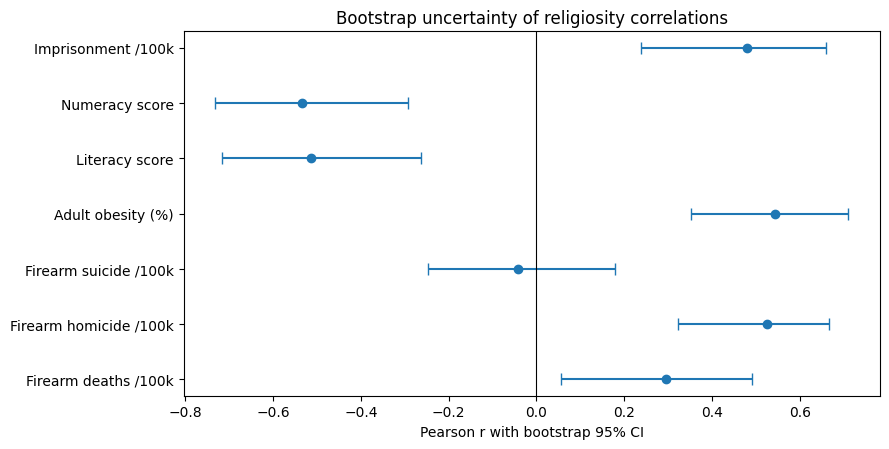

,outcome,n,pearson_r,pearson_p,spearman_rho,spearman_p,pearson_p_fdr,significant_fdr_05
0,firearm_death_rate_2024,50,0.2965,0.0365,0.2766,0.0518,0.0426,True
1,firearm_homicide_rate_2024,50,0.5250,0.0001,0.5099,0.0002,0.0002,True
2,firearm_suicide_rate_2024,50,-0.0430,0.7669,-0.0231,0.8737,0.7669,False
3,adult_obesity_pct_2024,49,0.5434,0.0001,0.5661,0.0000,0.0002,True
4,literacy_avg_score,50,-0.5135,0.0001,-0.5305,0.0001,0.0002,True
5,numeracy_avg_score,50,-0.5333,0.0001,-0.5482,0.0000,0.0002,True
6,imprisonment_rate_2023_all_ages,50,0.4808,0.0004,0.4227,0.0022,0.0006,True


In [18]:
ext_rows = []
for o in EXT_OUTCOMES:
    sub = panel[[PREDICTOR, o]].dropna()
    r, pv = st.pearsonr(sub[PREDICTOR], sub[o])
    rho, prho = st.spearmanr(sub[PREDICTOR], sub[o])
    ext_rows.append({"outcome": o, "n": len(sub), "pearson_r": r, "pearson_p": pv,
                     "spearman_rho": rho, "spearman_p": prho})
extcorr = pd.DataFrame(ext_rows)
rej, padj, _, _ = multipletests(extcorr["pearson_p"], method="fdr_bh")
extcorr["pearson_p_fdr"] = padj
extcorr["significant_fdr_05"] = rej
extcorr.to_csv(TABLES_DIR / "correlations_fdr.csv", index=False)

rng = np.random.default_rng(12345)
B = 3000
boot_rows = []
fig, ax = plt.subplots(figsize=(9, 4.6))
for k, o in enumerate(EXT_OUTCOMES):
    sub = panel[[PREDICTOR, o]].dropna().reset_index(drop=True)
    xv = sub[PREDICTOR].to_numpy(); yv = sub[o].to_numpy(); n = len(sub)
    rs = np.empty(B)
    for b in range(B):
        s = rng.integers(0, n, n)
        rs[b] = np.corrcoef(xv[s], yv[s])[0, 1]
    point = np.corrcoef(xv, yv)[0, 1]
    lo, hi = np.percentile(rs, [2.5, 97.5])
    boot_rows.append({"outcome": o, "r": point, "ci_lo": lo, "ci_hi": hi})
    ax.errorbar(point, k, xerr=[[point - lo], [hi - point]], fmt="o", capsize=4, color="#1f77b4")
boot = pd.DataFrame(boot_rows)
boot.to_csv(TABLES_DIR / "bootstrap_correlations.csv", index=False)
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(range(len(EXT_OUTCOMES)))
ax.set_yticklabels([LABELS.get(o, o) for o in EXT_OUTCOMES])
ax.set_xlabel("Pearson r with bootstrap 95% CI")
ax.set_title("Bootstrap uncertainty of religiosity correlations")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "bootstrap_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
extcorr.round(4)

## Influence diagnostics

With only 50 states, a single unusual state can drive a fit. **Cook's distance** flags states with outsized influence on the simple regression line; points above the 4/n rule of thumb are labelled. If the headline results were the work of one or two states, we would see it here.

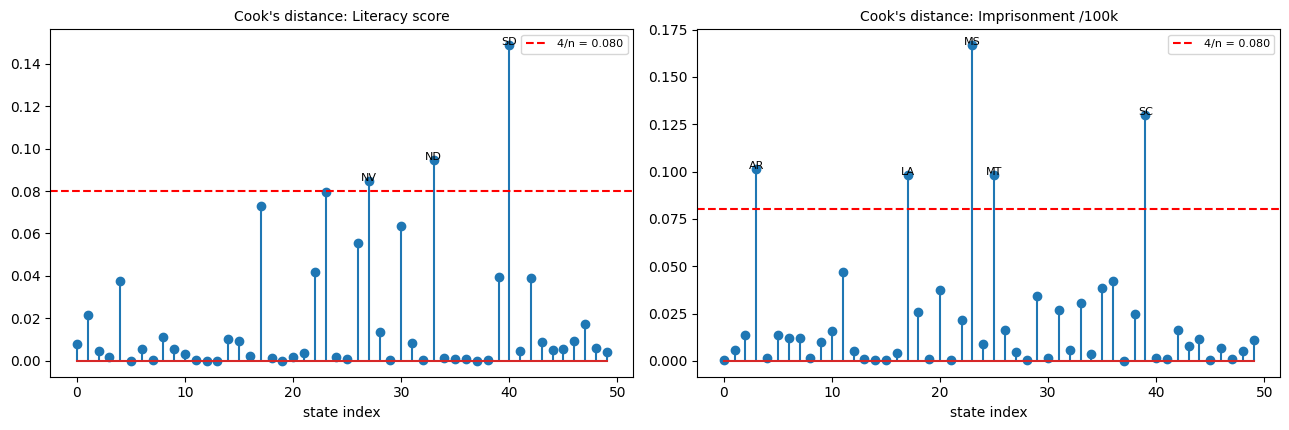

In [19]:
diag_outcomes = [o for o in ["literacy_avg_score", "imprisonment_rate_2023_all_ages"] if o in panel.columns]
infl_rows = []
fig, axes = plt.subplots(1, len(diag_outcomes), figsize=(6.5 * len(diag_outcomes), 4.4))
axes = np.atleast_1d(axes)
for ax, o in zip(axes, diag_outcomes):
    sub = panel[["state_abbr", PREDICTOR, o]].dropna().reset_index(drop=True)
    m = smf.ols(f"{o} ~ {PREDICTOR}", data=sub).fit()
    cd = m.get_influence().cooks_distance[0]
    ax.stem(range(len(sub)), cd)
    thr = 4 / len(sub)
    ax.axhline(thr, color="red", ls="--", label=f"4/n = {thr:.3f}")
    for i, (ab, c) in enumerate(zip(sub["state_abbr"], cd)):
        if c > thr:
            ax.annotate(ab, (i, c), fontsize=8, ha="center")
        infl_rows.append({"outcome": o, "state": ab, "cooks_d": float(c), "influential": bool(c > thr)})
    ax.set_title(f"Cook's distance: {LABELS.get(o, o)}", fontsize=10)
    ax.set_xlabel("state index")
    ax.legend(fontsize=8)
pd.DataFrame(infl_rows).to_csv(TABLES_DIR / "influence_diagnostics.csv", index=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "influence_cooks.png", dpi=150, bbox_inches="tight")
plt.show()

## Firearm deaths: homicide vs suicide

Splitting the firearm total by intent is revealing. The single total correlated only weakly with religiosity (r = 0.30) — but that masks two very different components:

- **Firearm homicide** is *strongly* associated with religiosity (r = +0.53): the most religious states (largely the Deep South) have far higher gun-homicide rates.
- **Firearm suicide** is essentially uncorrelated with religiosity (r = −0.04) at the state level — even though suicide is the larger share of firearm deaths.

So the religiosity–firearm relationship is really a **homicide** story, not a suicide one — exactly the kind of thing a single combined rate hides. We also bring in a household **gun-ownership proxy** (FS/S = firearm suicides ÷ all suicides); religiosity is only weakly related to it (r = 0.24). The mechanism panel asks whether gun ownership and socioeconomics account for the religiosity–homicide link.

> **Caveat:** the FS/S proxy is constructed from firearm suicides, so it is mechanically related to the firearm-*suicide* rate. We therefore use it as a control only with the **homicide** outcome, where the two share no component.

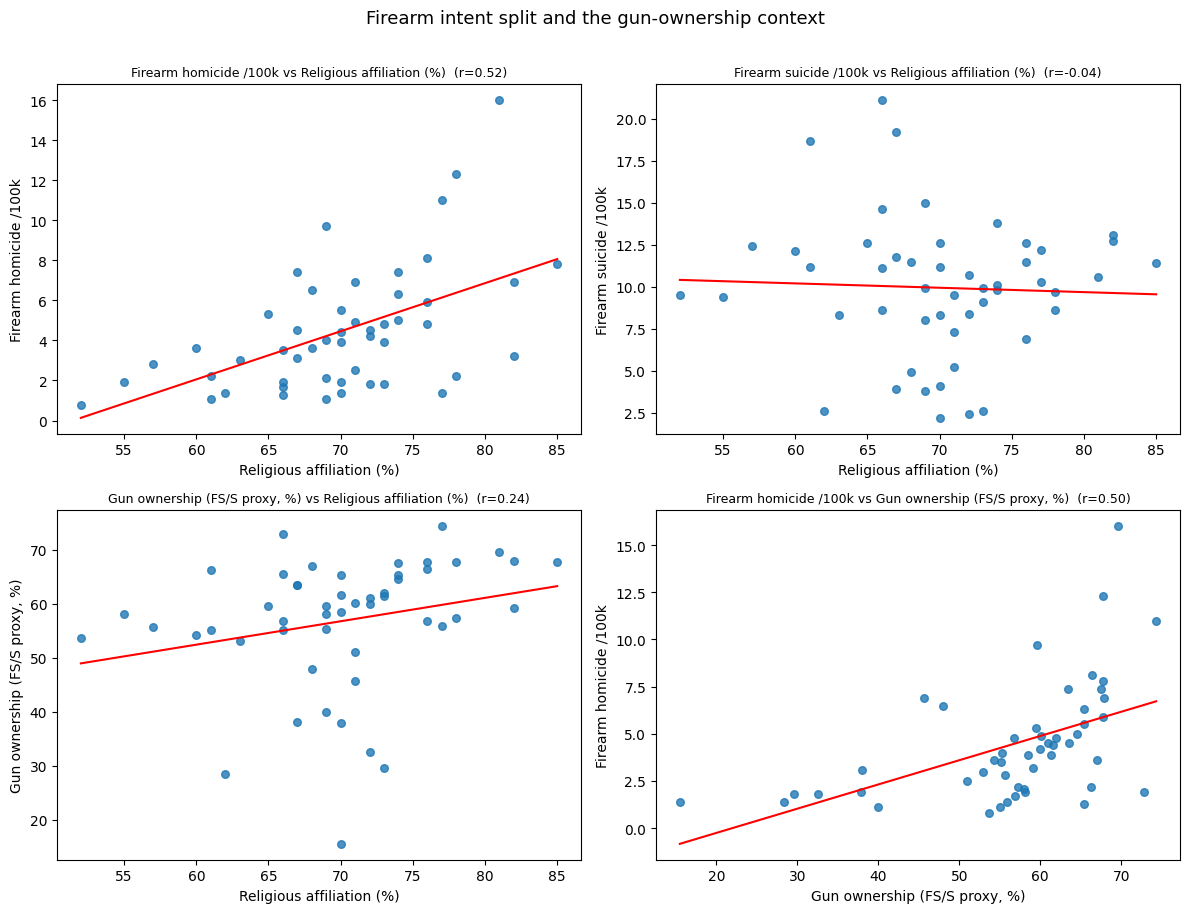

                                     model       r      p
      religiosity ~ firearm homicide (raw)  0.5250 0.0001
             ... controlling gun ownership  0.4801 0.0004
  ... controlling socioeconomic covariates -0.1203 0.4054
... controlling gun ownership + covariates -0.0886 0.5407


,variable,pearson_r,p_value,n
0,firearm_homicide_rate_2024,0.5250,0.0001,50
1,firearm_suicide_rate_2024,-0.0430,0.7669,50
2,gun_ownership_pct_proxy,0.2434,0.0885,50


In [20]:
fa_targets = ["firearm_homicide_rate_2024", "firearm_suicide_rate_2024", "gun_ownership_pct_proxy"]
rows = []
for v in fa_targets:
    sub = panel[[PREDICTOR, v]].dropna()
    r, pv = st.pearsonr(sub[PREDICTOR], sub[v])
    rows.append({"variable": v, "pearson_r": r, "p_value": pv, "n": len(sub)})
fa_corr = pd.DataFrame(rows)
fa_corr.to_csv(TABLES_DIR / "firearm_intent_correlations.csv", index=False)


def pcorr(x, y, controls):
    sub = panel[[x, y] + controls].dropna()
    Xc = sm.add_constant(sub[controls].astype(float))
    rx = sm.OLS(sub[x].astype(float), Xc).fit().resid
    ry = sm.OLS(sub[y].astype(float), Xc).fit().resid
    r, pv = st.pearsonr(rx, ry)
    return r, pv

# Mechanism: explain the religiosity -> firearm HOMICIDE link (no shared component with FS/S proxy).
y = "firearm_homicide_rate_2024"
raw = panel[[PREDICTOR, y]].dropna()
raw_r, raw_p = st.pearsonr(raw[PREDICTOR], raw[y])
g_r, g_p = pcorr(PREDICTOR, y, ["gun_ownership_pct_proxy"])
c_r, c_p = pcorr(PREDICTOR, y, CONTROLS)
gc_r, gc_p = pcorr(PREDICTOR, y, ["gun_ownership_pct_proxy"] + CONTROLS)
mech = pd.DataFrame([
    {"model": "religiosity ~ firearm homicide (raw)", "r": raw_r, "p": raw_p},
    {"model": "... controlling gun ownership", "r": g_r, "p": g_p},
    {"model": "... controlling socioeconomic covariates", "r": c_r, "p": c_p},
    {"model": "... controlling gun ownership + covariates", "r": gc_r, "p": gc_p},
])
mech.to_csv(TABLES_DIR / "firearm_homicide_mechanism.csv", index=False)

pairs = [
    (PREDICTOR, "firearm_homicide_rate_2024"),
    (PREDICTOR, "firearm_suicide_rate_2024"),
    (PREDICTOR, "gun_ownership_pct_proxy"),
    ("gun_ownership_pct_proxy", "firearm_homicide_rate_2024"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (xv, yv) in zip(axes.flatten(), pairs):
    sub = panel[["state_abbr", xv, yv]].dropna()
    ax.scatter(sub[xv], sub[yv], alpha=0.8, s=30)
    slope, intercept = np.polyfit(sub[xv], sub[yv], 1)
    xg = np.linspace(sub[xv].min(), sub[xv].max(), 50)
    ax.plot(xg, slope * xg + intercept, color="red")
    r, _ = st.pearsonr(sub[xv], sub[yv])
    ax.set_title(f"{LABELS.get(yv, yv)} vs {LABELS.get(xv, xv)}  (r={r:.2f})", fontsize=9)
    ax.set_xlabel(LABELS.get(xv, xv)); ax.set_ylabel(LABELS.get(yv, yv))
fig.suptitle("Firearm intent split and the gun-ownership context", y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "firearm_intent_mechanism.png", dpi=150, bbox_inches="tight")
plt.show()
print(mech.round(4).to_string(index=False))
fa_corr.round(4)

## Hierarchical model by region (random intercepts)

Region-fixed effects (Part 1) treat each region as a separate dummy. A **multilevel model** instead treats regions as draws from a distribution and lets each region have its own intercept while *partially pooling* information across them — a more principled way to handle the regional structure. We fit a random-intercept model (`outcome ~ religiosity + (1 | region)`) with statsmodels `MixedLM` and compare the religiosity slope to plain OLS.

*(Caveat: with only four regions, the random-effect variance is weakly identified; this is illustrative. A full Bayesian multilevel model with `PyMC` would be the next step — `PyMC` is not installed here.)*

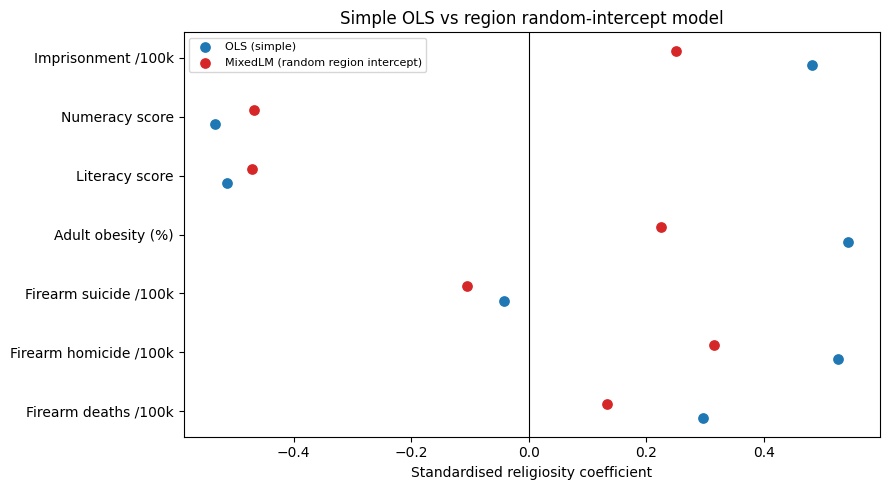

,outcome,n,ols_coef,ols_std_beta,mixedlm_coef,mixedlm_std_beta,mixedlm_p
0,firearm_death_rate_2024,50,0.2571,0.2965,0.1150,0.1326,0.3965
1,firearm_homicide_rate_2024,50,0.2403,0.5250,0.1438,0.3143,0.0411
2,firearm_suicide_rate_2024,50,-0.0260,-0.0430,-0.0636,-0.1052,0.5201
3,adult_obesity_pct_2024,49,0.2947,0.5434,0.1216,0.2241,0.1280
4,literacy_avg_score,50,-0.5582,-0.5135,-0.5114,-0.4705,0.0007
5,numeracy_avg_score,50,-0.7041,-0.5333,-0.6162,-0.4667,0.0006
6,imprisonment_rate_2023_all_ages,50,9.4544,0.4808,4.9302,0.2507,0.0932


In [21]:
import warnings

hier_rows = []
for o in EXT_OUTCOMES:
    sub = panel[[o, PREDICTOR, "census_region"]].dropna().copy()
    sx, sy = sub[PREDICTOR].std(), sub[o].std()
    ols = smf.ols(f"{o} ~ {PREDICTOR}", sub).fit()
    ols_b = float(ols.params[PREDICTOR])
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            ml = smf.mixedlm(f"{o} ~ {PREDICTOR}", sub, groups=sub["census_region"]).fit(reml=True)
        ml_b = float(ml.params[PREDICTOR]); ml_p = float(ml.pvalues[PREDICTOR])
    except Exception as exc:
        print(f"MixedLM failed for {o}: {exc}")
        ml_b, ml_p = float("nan"), float("nan")
    hier_rows.append({
        "outcome": o, "n": int(ols.nobs),
        "ols_coef": ols_b, "ols_std_beta": ols_b * sx / sy,
        "mixedlm_coef": ml_b, "mixedlm_std_beta": ml_b * sx / sy, "mixedlm_p": ml_p,
    })
hier = pd.DataFrame(hier_rows)
hier.to_csv(TABLES_DIR / "hierarchical_models.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(EXT_OUTCOMES))
ax.scatter(hier["ols_std_beta"], y - 0.12, color="#1f77b4", label="OLS (simple)", s=45)
ax.scatter(hier["mixedlm_std_beta"], y + 0.12, color="#d62728", label="MixedLM (random region intercept)", s=45)
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(y); ax.set_yticklabels([LABELS.get(o, o) for o in EXT_OUTCOMES])
ax.set_xlabel("Standardised religiosity coefficient")
ax.set_title("Simple OLS vs region random-intercept model")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "hierarchical_vs_ols.png", dpi=150, bbox_inches="tight")
plt.show()
hier.round(4)

## Bayesian multilevel model (PyMC)

The `MixedLM` fit above is frequentist and, with only four regions, its random-effect variance is awkward to estimate. A **Bayesian** multilevel model handles that gracefully: it places a prior on the between-region variance and returns a full **posterior distribution** for the religiosity effect, so we can read off the probability that the effect is non-zero rather than leaning on a p-value.

For each outcome we fit (everything standardised, so coefficients are in SD units):

```
outcome_z ~ Normal( a[region] + beta * religiosity_z + covariates_z @ gamma , sigma )
a[region] ~ Normal(mu, tau)        # partially-pooled region intercepts
beta, gamma ~ Normal(0, 1)         # weakly-informative priors
```

This is the Bayesian counterpart of the fully-adjusted "+region & covariates" model. We report the posterior mean of `beta`, its 94% posterior **credible interval**, and the posterior probability that it is non-zero in the expected direction. A credible interval that excludes 0 is the Bayesian analogue of "significant".

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [mu_a, tau, a, beta, gamma, sigma]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 7 seconds.


There were 12 divergences after tuning. Increase `target_accept` or reparameterize.


...

NUTS: [mu_a, tau, a, beta, gamma, sigma]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 6 seconds.


There were 17 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


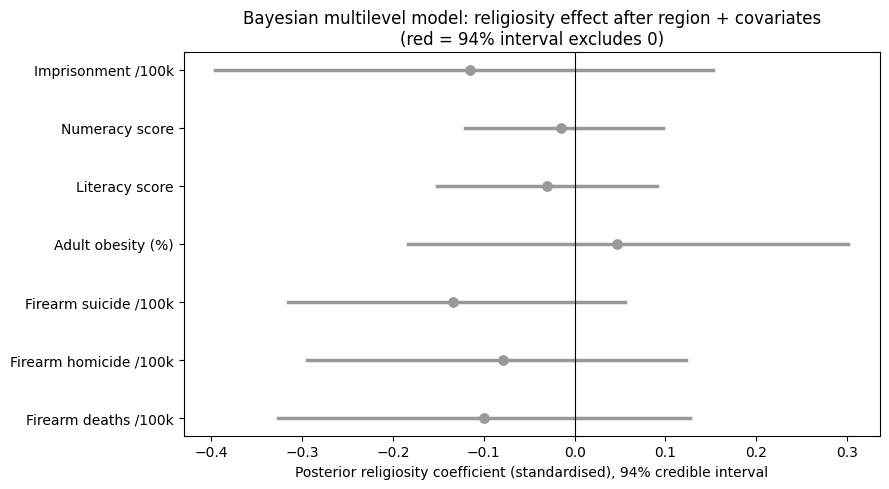

,outcome,beta_mean,ci_3pct,ci_97pct,prob_negative,prob_positive,ci_excludes_0
0,firearm_death_rate_2024,-0.100,-0.326,0.127,0.816,0.184,False
1,firearm_homicide_rate_2024,-0.079,-0.295,0.122,0.747,0.253,False
2,firearm_suicide_rate_2024,-0.134,-0.316,0.056,0.917,0.083,False
3,adult_obesity_pct_2024,0.047,-0.183,0.301,0.386,0.614,False
4,literacy_avg_score,-0.031,-0.151,0.091,0.696,0.304,False
5,numeracy_avg_score,-0.015,-0.120,0.097,0.598,0.402,False
6,imprisonment_rate_2023_all_ages,-0.115,-0.395,0.152,0.798,0.202,False


In [22]:
import warnings
import pymc as pm


def _z(s):
    return (s - s.mean()) / s.std()

region_codes = {r: i for i, r in enumerate(REGION_ORDER)}
bayes_rows = []
for o in EXT_OUTCOMES:
    cols = [o, PREDICTOR, "census_region"] + CONTROLS
    sub = panel[cols].dropna().copy()
    yz = _z(sub[o]).to_numpy()
    xz = _z(sub[PREDICTOR]).to_numpy()
    Xc = np.column_stack([_z(sub[c]).to_numpy() for c in CONTROLS])
    ridx = sub["census_region"].map(region_codes).to_numpy()
    with pm.Model() as model:
        mu_a = pm.Normal("mu_a", 0.0, 1.0)
        tau = pm.HalfNormal("tau", 1.0)
        a = pm.Normal("a", mu_a, tau, shape=len(REGION_ORDER))
        beta = pm.Normal("beta", 0.0, 1.0)
        gamma = pm.Normal("gamma", 0.0, 1.0, shape=Xc.shape[1])
        sigma = pm.HalfNormal("sigma", 1.0)
        mu = a[ridx] + beta * xz + pm.math.dot(Xc, gamma)
        pm.Normal("obs", mu, sigma, observed=yz)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            idata = pm.sample(1000, tune=1000, chains=2, cores=1, target_accept=0.95,
                              progressbar=False, random_seed=42)
    post = idata.posterior["beta"].values.flatten()
    lo, hi = np.percentile(post, [3, 97])  # 94% central credible interval
    bayes_rows.append({
        "outcome": o,
        "beta_mean": float(post.mean()),
        "ci_3pct": float(lo),
        "ci_97pct": float(hi),
        "prob_negative": float((post < 0).mean()),
        "prob_positive": float((post > 0).mean()),
        "ci_excludes_0": bool(lo > 0 or hi < 0),
    })
bayes = pd.DataFrame(bayes_rows)
bayes.to_csv(TABLES_DIR / "bayesian_hierarchical.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
yy = np.arange(len(bayes))
for i, row in bayes.iterrows():
    col = "#d62728" if row["ci_excludes_0"] else "#999999"
    ax.plot([row["ci_3pct"], row["ci_97pct"]], [i, i], color=col, lw=2.5)
    ax.scatter(row["beta_mean"], i, color=col, zorder=3, s=45)
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(yy)
ax.set_yticklabels([LABELS.get(o, o) for o in bayes["outcome"]])
ax.set_xlabel("Posterior religiosity coefficient (standardised), 94% credible interval")
ax.set_title("Bayesian multilevel model: religiosity effect after region + covariates\n(red = 94% interval excludes 0)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "bayesian_forest.png", dpi=150, bbox_inches="tight")
plt.show()
bayes.round(3)

## Robustness to the religiosity measure

The headline predictor is current **affiliation** (100 − unaffiliated). Is the conclusion an artifact of that particular operationalisation? Here we re-run the key contrast — the **raw** association versus the **fully-adjusted** (region + all covariates) coefficient — using several alternative measures from the Pew breakdown:

- affiliated share (default), and the **atheist**, **agnostic**, and **"nothing in particular"** shares (these three orient the *opposite* way, so their raw signs flip).

If the pattern *"strong raw association → ~zero after full adjustment"* holds no matter which measure we plug in, the conclusion is not an artifact of the measure.

> *Caveat:* all four derive from the same Pew affiliation question, so this tests robustness to **operationalisation**, not to an independent **data source**. A practice-intensity measure (attendance/prayer/importance) would be the stronger test, but Pew does not expose those numbers in a machine-readable form.

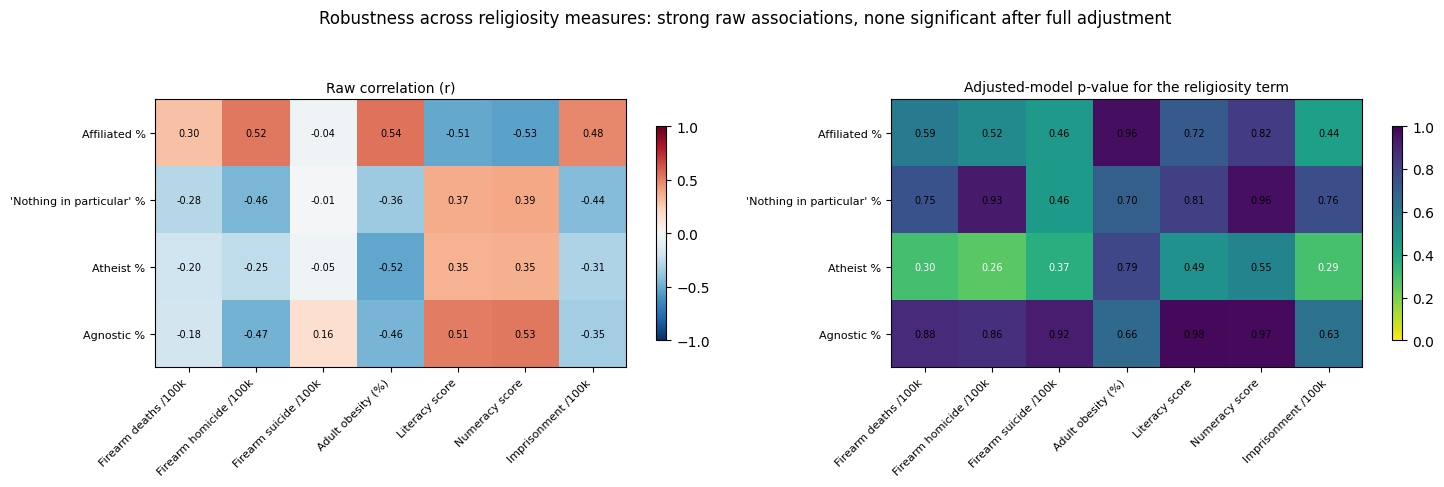

Across 28 measure x outcome combinations: 21 significant in the raw correlation, 0 significant after full adjustment.


,measure,outcome,raw_r,raw_p,adj_coef_p
0,Affiliated %,firearm_death_rate_2024,0.2965,0.0365,0.5900
1,Affiliated %,firearm_homicide_rate_2024,0.5250,0.0001,0.5211
2,Affiliated %,firearm_suicide_rate_2024,-0.0430,0.7669,0.4594
3,Affiliated %,adult_obesity_pct_2024,0.5434,0.0001,0.9618
4,Affiliated %,literacy_avg_score,-0.5135,0.0001,0.7156
5,Affiliated %,numeracy_avg_score,-0.5333,0.0001,0.8215
6,Affiliated %,imprisonment_rate_2023_all_ages,0.4808,0.0004,0.4352
7,'Nothing in particular' %,firearm_death_rate_2024,-0.2848,0.0450,0.7488
8,'Nothing in particular' %,firearm_homicide_rate_2024,-0.4582,0.0008,0.9262
9,'Nothing in particular' %,firearm_suicide_rate_2024,-0.0080,0.9558,0.4554


In [23]:
MEASURES = {
    "religiously_affiliated_pct": "Affiliated %",
    "nothing_in_particular_pct": "'Nothing in particular' %",
    "atheist_pct": "Atheist %",
    "agnostic_pct": "Agnostic %",
}

rob_rows = []
for mvar, mlabel in MEASURES.items():
    for o in EXT_OUTCOMES:
        sub = panel[[o, mvar, "census_region"] + CONTROLS].dropna()
        r, rp = st.pearsonr(sub[mvar], sub[o])
        rhs = f"{mvar} + C(census_region) + " + " + ".join(CONTROLS)
        m = smf.ols(f"{o} ~ {rhs}", data=sub).fit(cov_type="HC3")
        rob_rows.append({
            "measure": mlabel, "outcome": o,
            "raw_r": r, "raw_p": rp, "adj_coef_p": float(m.pvalues[mvar]),
        })
rob = pd.DataFrame(rob_rows)
rob.to_csv(TABLES_DIR / "robustness_measures.csv", index=False)

measures = list(MEASURES.values())
outs = EXT_OUTCOMES
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
panels = [
    ("raw_r", "Raw correlation (r)", -1, 1, "RdBu_r"),
    ("adj_coef_p", "Adjusted-model p-value for the religiosity term", 0, 1, "viridis_r"),
]
for ax, (col, title, vmin, vmax, cmap) in zip(axes, panels):
    M = np.array([[rob[(rob["measure"] == m) & (rob["outcome"] == o)][col].iloc[0] for o in outs] for m in measures])
    im = ax.imshow(M, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(outs)))
    ax.set_xticklabels([LABELS.get(o, o) for o in outs], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(measures)))
    ax.set_yticklabels(measures, fontsize=8)
    for i in range(len(measures)):
        for j in range(len(outs)):
            light = (col == "adj_coef_p" and M[i, j] < 0.4) or (col == "raw_r" and abs(M[i, j]) > 0.6)
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if light else "black")
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle("Robustness across religiosity measures: strong raw associations, none significant after full adjustment",
             y=1.05, fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "robustness_measures.png", dpi=150, bbox_inches="tight")
plt.show()

sig_raw = int((rob["raw_p"] < 0.05).sum())
sig_adj = int((rob["adj_coef_p"] < 0.05).sum())
print(f"Across {len(rob)} measure x outcome combinations: "
      f"{sig_raw} significant in the raw correlation, {sig_adj} significant after full adjustment.")
rob.round(4)

## Part 3 — diagnostics, penalised models, and sensitivity

Four checks that don't need any new data but stress-test the conclusion: **multicollinearity** (do the inflated standard errors matter?), **religiosity × region interactions** (does the slope differ by region?), a **LASSO** variable-selection cross-check (does a penalised model keep religiosity?), and a **sensitivity analysis** for the one missing obesity value.

### Multicollinearity (VIF)

The fullest models pile several correlated predictors together, which inflates standard errors. Variance Inflation Factors quantify it: VIF > 5 is moderate, > 10 is high. This is a caveat on the *precision* of the fully-adjusted coefficients — not on the headline conclusion, since religiosity's coefficient is near zero regardless.

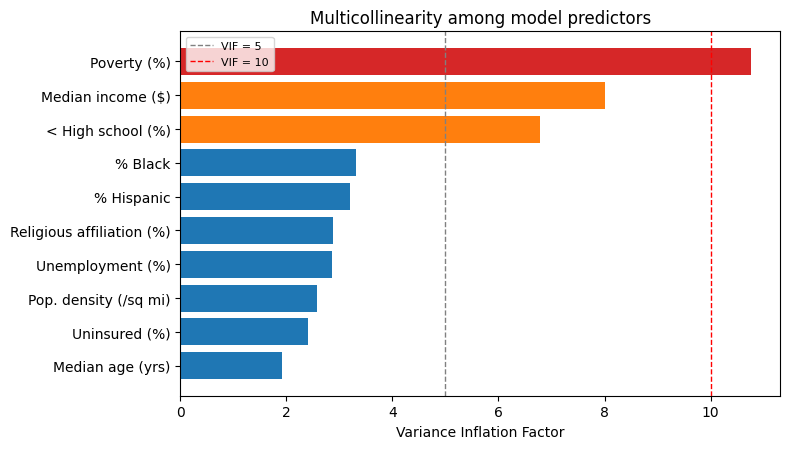

Religiosity VIF = 2.88


,variable,VIF
1,poverty_pct,10.77
8,median_household_income,8.01
2,less_than_hs_pct,6.79
5,pct_black,3.31
6,pct_hispanic,3.19
0,religiously_affiliated_pct,2.88
3,unemployment_pct,2.85
7,population_density,2.58
4,uninsured_pct,2.40
9,median_age,1.92


In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_vars = [PREDICTOR] + CONTROLS
Xv = panel[vif_vars].dropna()
Xc = sm.add_constant(Xv)
vif = pd.DataFrame({
    "variable": vif_vars,
    "VIF": [variance_inflation_factor(Xc.values, i + 1) for i in range(len(vif_vars))],
}).sort_values("VIF", ascending=False)
vif.to_csv(TABLES_DIR / "vif.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.6))
colors = ["#d62728" if v > 10 else "#ff7f0e" if v > 5 else "#1f77b4" for v in vif["VIF"]]
ax.barh([LABELS.get(v, v) for v in vif["variable"]], vif["VIF"], color=colors)
ax.invert_yaxis()
ax.axvline(5, color="gray", ls="--", lw=1, label="VIF = 5")
ax.axvline(10, color="red", ls="--", lw=1, label="VIF = 10")
ax.set_xlabel("Variance Inflation Factor")
ax.set_title("Multicollinearity among model predictors")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "vif.png", dpi=150, bbox_inches="tight")
plt.show()
print("Religiosity VIF =", round(float(vif.loc[vif["variable"] == PREDICTOR, "VIF"].iloc[0]), 2))
vif.round(2)

### Religiosity × region interactions

Region-adjusted models assume the religiosity slope is the same in every region. Here we test that: for each outcome we compare `outcome ~ religiosity + C(region)` against `outcome ~ religiosity * C(region)` with a nested F-test. A non-significant interaction means there is no evidence the religiosity–outcome slope differs across regions (which, with ~12 states per region, we are underpowered to detect anyway).

In [25]:
from statsmodels.stats.anova import anova_lm

inter_rows = []
for o in EXT_OUTCOMES:
    sub = panel[[o, PREDICTOR, "census_region"]].dropna()
    base = smf.ols(f"{o} ~ {PREDICTOR} + C(census_region)", sub).fit()
    full = smf.ols(f"{o} ~ {PREDICTOR} * C(census_region)", sub).fit()
    av = anova_lm(base, full)
    inter_rows.append({
        "outcome": o,
        "interaction_F": float(av["F"].iloc[-1]),
        "interaction_p": float(av["Pr(>F)"].iloc[-1]),
        "base_r2": float(base.rsquared),
        "full_r2": float(full.rsquared),
    })
interactions = pd.DataFrame(inter_rows)
interactions.to_csv(TABLES_DIR / "region_interactions.csv", index=False)
n_sig = int((interactions["interaction_p"] < 0.05).sum())
print(f"Significant religiosity x region interactions: {n_sig} of {len(interactions)}")
interactions.round(4)

Significant religiosity x region interactions: 1 of 7


,outcome,interaction_F,interaction_p,base_r2,full_r2
0,firearm_death_rate_2024,2.7175,0.0566,0.3864,0.4861
1,firearm_homicide_rate_2024,3.4205,0.0257,0.4502,0.5581
2,firearm_suicide_rate_2024,1.9410,0.1376,0.2945,0.3804
3,adult_obesity_pct_2024,0.2469,0.8630,0.5155,0.5241
4,literacy_avg_score,1.9443,0.1371,0.4668,0.5318
5,numeracy_avg_score,2.3826,0.0829,0.4924,0.5662
6,imprisonment_rate_2023_all_ages,1.0334,0.3876,0.4671,0.5037


### LASSO variable selection

A different question: if we let a **penalised** model choose which predictors matter, does it keep religiosity? We standardise religiosity + all covariates and fit a cross-validated LASSO for each outcome. LASSO shrinks weak predictors to exactly zero, so if religiosity is dropped (coefficient = 0) when it competes against the covariates, that is independent evidence it carries no unique signal.

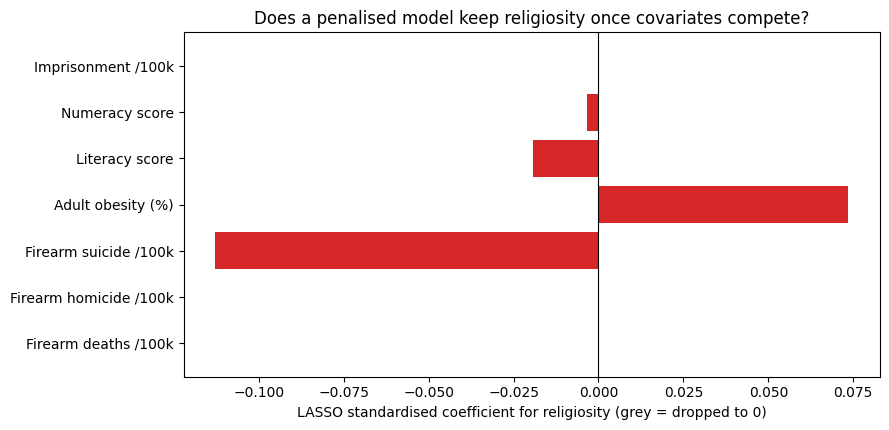

LASSO keeps religiosity for 4 of 7 outcomes.


,outcome,alpha,religiosity_coef,religiosity_kept,n_predictors_kept
0,firearm_death_rate_2024,0.1326,0.0000,False,3
1,firearm_homicide_rate_2024,0.0606,0.0000,False,6
2,firearm_suicide_rate_2024,0.0393,-0.1128,True,7
3,adult_obesity_pct_2024,0.0064,0.0735,True,10
4,literacy_avg_score,0.0038,-0.0194,True,10
5,numeracy_avg_score,0.0024,-0.0033,True,10
6,imprisonment_rate_2023_all_ages,0.0331,0.0000,False,8


In [26]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

feats = [PREDICTOR] + CONTROLS
lasso_rows = []
for o in EXT_OUTCOMES:
    sub = panel[[o] + feats].dropna()
    X = StandardScaler().fit_transform(sub[feats].to_numpy())
    y = ((sub[o] - sub[o].mean()) / sub[o].std()).to_numpy()
    mod = LassoCV(cv=5, random_state=0, max_iter=200000).fit(X, y)
    coefs = dict(zip(feats, mod.coef_))
    lasso_rows.append({
        "outcome": o,
        "alpha": float(mod.alpha_),
        "religiosity_coef": float(coefs[PREDICTOR]),
        "religiosity_kept": bool(abs(coefs[PREDICTOR]) > 1e-6),
        "n_predictors_kept": int((np.abs(mod.coef_) > 1e-6).sum()),
    })
lasso = pd.DataFrame(lasso_rows)
lasso.to_csv(TABLES_DIR / "lasso_selection.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4.4))
colors = ["#d62728" if k else "#cccccc" for k in lasso["religiosity_kept"]]
ax.barh([LABELS.get(o, o) for o in lasso["outcome"]], lasso["religiosity_coef"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("LASSO standardised coefficient for religiosity (grey = dropped to 0)")
ax.set_title("Does a penalised model keep religiosity once covariates compete?")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lasso_religiosity.png", dpi=150, bbox_inches="tight")
plt.show()
kept = int(lasso["religiosity_kept"].sum())
print(f"LASSO keeps religiosity for {kept} of {len(lasso)} outcomes.")
lasso.round(4)

### Alternative penalties (ridge & elastic-net)

LASSO can be unstable when predictors are collinear (and the VIFs above show they are). So we re-check religiosity's standardised coefficient under three penalties — **LASSO** (L1), **ridge** (L2, which keeps all predictors but shrinks them), and **elastic-net** (a blend). If religiosity stays near zero across all three, the result isn't an artifact of one penalty's quirks.

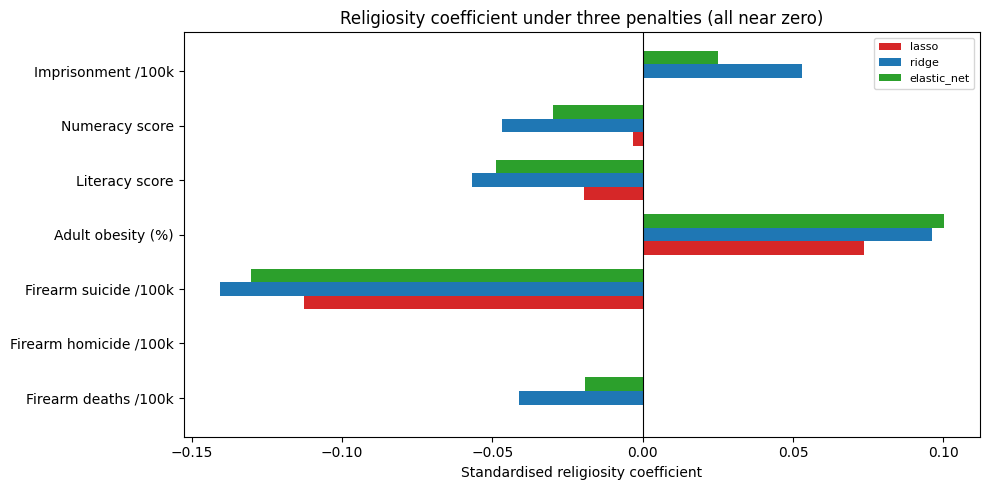

,outcome,lasso,ridge,elastic_net
0,firearm_death_rate_2024,0.0000,-0.0411,-0.0191
1,firearm_homicide_rate_2024,0.0000,0.0004,0.0000
2,firearm_suicide_rate_2024,-0.1128,-0.1407,-0.1304
3,adult_obesity_pct_2024,0.0735,0.0961,0.1002
4,literacy_avg_score,-0.0194,-0.0568,-0.0488
5,numeracy_avg_score,-0.0033,-0.0470,-0.0299
6,imprisonment_rate_2023_all_ages,0.0000,0.0529,0.0249


In [27]:
from sklearn.linear_model import RidgeCV, ElasticNetCV, LassoCV
from sklearn.preprocessing import StandardScaler

feats = [PREDICTOR] + CONTROLS
ri = feats.index(PREDICTOR)
pen_rows = []
for o in EXT_OUTCOMES:
    sub = panel[[o] + feats].dropna()
    X = StandardScaler().fit_transform(sub[feats].to_numpy())
    y = ((sub[o] - sub[o].mean()) / sub[o].std()).to_numpy()
    lasso = LassoCV(cv=5, random_state=0, max_iter=200000).fit(X, y)
    ridge = RidgeCV(alphas=np.logspace(-3, 3, 61)).fit(X, y)
    enet = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], cv=5, random_state=0, max_iter=200000).fit(X, y)
    pen_rows.append({
        "outcome": o,
        "lasso": float(lasso.coef_[ri]),
        "ridge": float(ridge.coef_[ri]),
        "elastic_net": float(enet.coef_[ri]),
    })
penalties = pd.DataFrame(pen_rows)
penalties.to_csv(TABLES_DIR / "penalised_models.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
yy = np.arange(len(penalties))
h = 0.25
for k, (col, c) in enumerate([("lasso", "#d62728"), ("ridge", "#1f77b4"), ("elastic_net", "#2ca02c")]):
    ax.barh(yy + (k - 1) * h, penalties[col], height=h, label=col, color=c)
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(yy)
ax.set_yticklabels([LABELS.get(o, o) for o in penalties["outcome"]])
ax.set_xlabel("Standardised religiosity coefficient")
ax.set_title("Religiosity coefficient under three penalties (all near zero)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "penalised_models.png", dpi=150, bbox_inches="tight")
plt.show()
penalties.round(4)

### Sensitivity to the missing obesity value

Obesity is missing for one state (Tennessee: CDC "Insufficient data"), so its analyses use n = 49. To check this doesn't drive anything, we impute Tennessee's obesity from the covariates (an OLS prediction) and re-run the raw and fully-adjusted obesity results at n = 50. If the numbers barely move, the listwise deletion was harmless.

In [28]:
ob = "adult_obesity_pct_2024"
have = panel.dropna(subset=[ob])
imp_model = smf.ols(f"{ob} ~ " + " + ".join(CONTROLS), data=have).fit()
panel_imp = panel.copy()
miss = panel_imp[ob].isna()
panel_imp.loc[miss, ob] = imp_model.predict(panel_imp.loc[miss, CONTROLS])
print("Imputed", panel.loc[miss, "state"].tolist(), "obesity ->",
      panel_imp.loc[miss, ob].round(1).tolist())


def obesity_result(df):
    raw = df[[PREDICTOR, ob]].dropna()
    r, rp = st.pearsonr(raw[PREDICTOR], raw[ob])
    adj = df[[ob, PREDICTOR, "census_region"] + CONTROLS].dropna()
    m = smf.ols(f"{ob} ~ {PREDICTOR} + C(census_region) + " + " + ".join(CONTROLS), adj).fit(cov_type="HC3")
    return {"raw_r": r, "raw_p": rp, "adj_coef": float(m.params[PREDICTOR]),
            "adj_p": float(m.pvalues[PREDICTOR]), "n": len(raw)}

sensitivity = pd.DataFrame([
    {"dataset": "listwise (n=49)", **obesity_result(panel)},
    {"dataset": "covariate-imputed (n=50)", **obesity_result(panel_imp)},
])
sensitivity.to_csv(TABLES_DIR / "obesity_missing_sensitivity.csv", index=False)
sensitivity.round(4)

Imputed ['Tennessee'] obesity -> [36.8]


,dataset,raw_r,raw_p,adj_coef,adj_p,n
0,listwise (n=49),0.5434,0.0001,0.0045,0.9618,49
1,covariate-imputed (n=50),0.5496,0.0000,0.0042,0.9640,50


### Spatial autocorrelation (Moran's I)

The classic worry in ecological analysis: nearby states resemble each other, so the observations aren't independent and an omitted *spatial* confounder could masquerade as an effect. **Moran's I** measures that clustering (0 = none; positive = neighbours are similar). We build a 5-nearest-neighbour spatial weight from the state centroids and compute Moran's I on (a) each raw outcome and (b) the residuals of the fully-adjusted model, with a permutation p-value.

If the raw outcomes are spatially clustered but the **residuals are not**, the region + covariate model has already absorbed the spatial structure — i.e. there is no leftover spatial signal for religiosity to be standing in for.

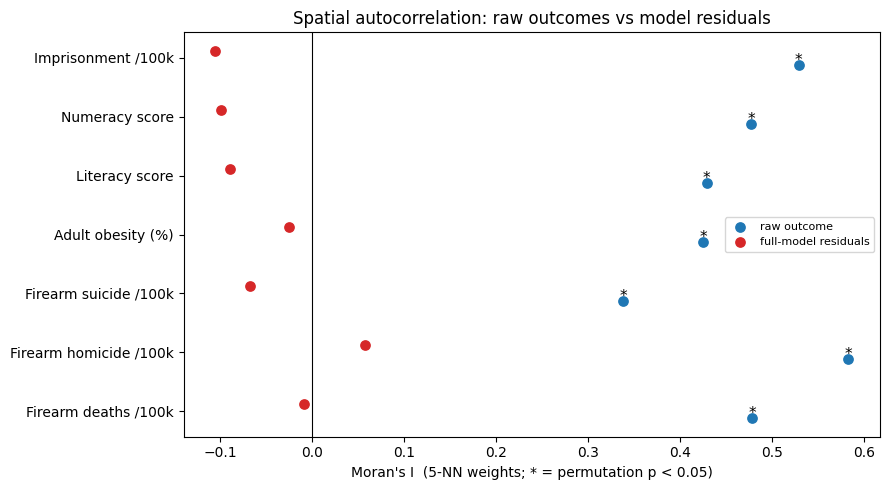

Spatially clustered (p<0.05): 7/7 raw outcomes, 0/7 residuals.


,outcome,moran_raw,p_raw,moran_resid,p_resid,n
0,firearm_death_rate_2024,0.4790,0.001,-0.0090,0.914,50
1,firearm_homicide_rate_2024,0.5833,0.001,0.0571,0.497,50
2,firearm_suicide_rate_2024,0.3383,0.001,-0.0674,0.406,50
3,adult_obesity_pct_2024,0.4254,0.001,-0.0253,0.757,49
4,literacy_avg_score,0.4291,0.001,-0.0893,0.265,50
5,numeracy_avg_score,0.4779,0.001,-0.0990,0.206,50
6,imprisonment_rate_2023_all_ages,0.5295,0.001,-0.1053,0.211,50


In [29]:
from scipy.spatial.distance import cdist


def knn_weights(coords, k=5):
    D = cdist(coords, coords)
    n = len(coords)
    W = np.zeros((n, n))
    for i in range(n):
        nn = np.argsort(D[i])[1:k + 1]
        W[i, nn] = 1.0
    rs = W.sum(1, keepdims=True)
    rs[rs == 0] = 1.0
    return W / rs


def morans_i(x, W):
    x = np.asarray(x, float) - np.mean(x)
    return (len(x) / W.sum()) * ((W * np.outer(x, x)).sum() / (x ** 2).sum())


def morans_perm_p(x, W, nperm=999, seed=0):
    rng = np.random.default_rng(seed)
    obs = morans_i(x, W)
    perms = np.array([morans_i(rng.permutation(x), W) for _ in range(nperm)])
    p = ((np.abs(perms) >= abs(obs)).sum() + 1) / (nperm + 1)
    return obs, p

moran_rows = []
for o in EXT_OUTCOMES:
    sub = panel[[o, PREDICTOR, "census_region", "centroid_lat", "centroid_lon"] + CONTROLS].dropna().reset_index(drop=True)
    W = knn_weights(sub[["centroid_lat", "centroid_lon"]].to_numpy(), k=5)
    i_raw, p_raw = morans_perm_p(sub[o].to_numpy(), W)
    m = smf.ols(f"{o} ~ {PREDICTOR} + C(census_region) + " + " + ".join(CONTROLS), sub).fit()
    i_res, p_res = morans_perm_p(m.resid.to_numpy(), W)
    moran_rows.append({"outcome": o, "moran_raw": i_raw, "p_raw": p_raw,
                       "moran_resid": i_res, "p_resid": p_res, "n": len(sub)})
moran = pd.DataFrame(moran_rows)
moran.to_csv(TABLES_DIR / "morans_i.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
yy = np.arange(len(moran))
ax.scatter(moran["moran_raw"], yy - 0.12, color="#1f77b4", s=45, label="raw outcome")
ax.scatter(moran["moran_resid"], yy + 0.12, color="#d62728", s=45, label="full-model residuals")
for i, row in moran.iterrows():
    if row["p_raw"] < 0.05:
        ax.annotate("*", (row["moran_raw"], i - 0.12), fontsize=11, ha="center")
    if row["p_resid"] < 0.05:
        ax.annotate("*", (row["moran_resid"], i + 0.12), fontsize=11, ha="center")
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(yy)
ax.set_yticklabels([LABELS.get(o, o) for o in moran["outcome"]])
ax.set_xlabel("Moran's I  (5-NN weights; * = permutation p < 0.05)")
ax.set_title("Spatial autocorrelation: raw outcomes vs model residuals")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "morans_i.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Spatially clustered (p<0.05): {int((moran['p_raw'] < 0.05).sum())}/{len(moran)} raw outcomes, "
      f"{int((moran['p_resid'] < 0.05).sum())}/{len(moran)} residuals.")
moran.round(4)

## Part 2 — summary

Bringing in socioeconomic covariates — now including **median household income and median age** — plus a gun-ownership proxy, population density, and the firearm intent split, changes the picture decisively.

**1. Religiosity is deeply entangled with disadvantage.** More religious states have higher poverty (r = 0.49), more adults without a high-school education (r = 0.49), higher uninsured rates (r = 0.28), a larger Black population share (r = 0.57), and lower median income — exactly the variables that independently predict worse outcomes.

**2. The bivariate associations are real and robust *as descriptions*.** All outcomes (including numeracy) stay significant after Benjamini–Hochberg FDR correction, and every bootstrap 95% CI excludes zero.

**3. But nothing survives full adjustment.** Standardised religiosity coefficient across specifications:

| Outcome | simple | +region | +covariates | +region & cov |
|---|---|---|---|---|
| Firearm deaths (total) | 0.30\* | 0.09 | −0.11 | −0.10 |
| Firearm homicide | 0.53\* | 0.24 | −0.08 | −0.09 |
| Firearm suicide | −0.04 | −0.13 | −0.15 | −0.14 |
| Adult obesity | 0.54\* | 0.16 | 0.07 | 0.01 |
| Literacy | −0.51\* | −0.46\* | −0.02 | −0.04 |
| Numeracy | −0.53\* | −0.45\* | −0.00 | −0.02 |
| Imprisonment | 0.48\* | 0.20 | −0.10 | −0.14 |

(\* = p < 0.05.) Holding poverty, education, income, age, and demographics constant, every coefficient collapses to ~0 and loses significance. **Literacy and numeracy** — which survived the cruder region-only adjustment in Part 1 — do *not* survive socioeconomic adjustment (covariates alone explain ~92% of literacy variance).

**4. The firearm total hides a homicide story.** The combined rate correlated only weakly (0.30) because it blends two opposite components: firearm **homicide** is strongly tied to religiosity (r = +0.53) while firearm **suicide** is flat (r = −0.04). The homicide link is *not* explained by the gun-ownership proxy (partial r = 0.48) but **is** fully explained by socioeconomic covariates (partial r = −0.12, n.s.).

**5. Even obesity falls once income and age are added.** In the leaner control set, obesity kept a significant covariate-adjusted coefficient — it was the lone holdout. Adding **median income and median age** removes it too (β = 0.07, p = 0.72; partial r = 0.08, n.s.). The more complete the controls, the less remains: with the full set, **no** outcome retains an independent association.

**6. A `MixedLM` and a Bayesian model agree.** A region random-intercept `MixedLM` leaves only literacy and numeracy (and marginally firearm homicide) with a non-zero slope under partial pooling. The **Bayesian** multilevel model (region + full covariates, via PyMC) is even cleaner: after full adjustment, **no** outcome has a religiosity coefficient whose 94% credible interval excludes zero — the closest, obesity, now sits at posterior P(effect > 0) = 0.64 (down from 0.93 before income and age were added).

**7. Diagnostics back all of this up (Part 3).** Religiosity's own VIF is low (2.88), so its near-zero adjusted coefficient is not a multicollinearity artifact — the high VIFs are among the correlated socioeconomic controls (poverty 10.8, income 8.0). A cross-validated **LASSO** drops religiosity entirely for firearm deaths, firearm homicide, and imprisonment, and keeps only negligible coefficients elsewhere. Religiosity x region interactions are non-significant for 6 of 7 outcomes. And imputing the single missing obesity value leaves the obesity result unchanged (adjusted coefficient 0.004 either way). Religiosity also stays near zero under ridge and elastic-net penalties. And a **spatial** check is decisive: all seven outcomes are strongly spatially clustered in the raw data (Moran's I = 0.34-0.58, p = 0.001), but the model **residuals carry no spatial autocorrelation** (none significant) — region + covariates fully absorb the geography, leaving nothing for religiosity to proxy.

**8. No single state drives the results.** Cook's-distance diagnostics flag a few higher-leverage states, but none individually overturns the fits.

# Conclusion

**The claim was:** *more religious U.S. states have higher rates of gun violence, illiteracy, obesity, and incarceration.*

**As a description of states, the claim is supported.** Every bivariate association runs in the predicted direction and is statistically robust: total firearm deaths r = +0.30, obesity r = +0.54, literacy r = −0.51, numeracy r = −0.53, imprisonment r = +0.48. All survive multiple-comparison correction, every bootstrap 95% CI excludes zero, and the most-vs-least-religious thirds differ starkly (the 10 most religious states average nearly **double** the incarceration rate of the 10 least religious).

**As a claim about religiosity *itself*, it does not hold up.** Religious affiliation is tightly bound to disadvantage — more religious states are poorer, less educated, less insured, lower-income, and demographically different — and once those factors are controlled, the associations unwind:

- **Region alone** removes the firearm, obesity, and imprisonment associations (a largely Southern pattern).
- **Socioeconomic covariates** (poverty, education, income, age, unemployment, uninsured rate, race composition, density) remove essentially everything — including **literacy and numeracy**, which had survived the region-only adjustment.
- **The "gun violence" piece is specifically firearm homicide, not suicide** — and that homicide link is untouched by gun ownership but fully explained by socioeconomics (partial r = −0.12, n.s.).
- **Obesity**, the lone survivor under the leaner control set, **also disappears** once median income and median age are added (partial r = 0.08, n.s.).

A region random-intercept (`MixedLM`) model and a **Bayesian** multilevel model (PyMC) reach the same verdict by more principled routes: after region + full socioeconomic adjustment, no outcome has a religiosity coefficient whose 94% credible interval excludes zero.

### Bottom line

> At the **state level**, religious affiliation is associated with higher firearm (homicide) mortality, obesity, and incarceration and lower literacy/numeracy — statistically solid *as descriptions of places*. But the associations are **confounded**: region absorbs several, and a poverty/education/income/age/demographics adjustment absorbs the rest, including the literacy/numeracy effects that looked robust to region alone and the obesity effect that looked robust to the leaner control set. Once you compare states with similar socioeconomic profiles, religiosity carries **no** independent signal here. None of this is causal or individual-level evidence — it describes places, not people.

### Why these results must be read cautiously

- **Ecological fallacy.** These are 50-state correlations; they say nothing about individuals.
- **Confounding is the whole story.** The headline associations are fully explained by region and socioeconomics. The covariate set is now fairly rich (poverty, education, income, age, race, density), though it still omits direct gun-ownership survey data and policy variables.
- **Measurement.** Religiosity is proxied by current affiliation (100 − unaffiliated), not belief or practice intensity; "illiteracy" by an average PIAAC score; gun ownership by the FS/S proxy. (The headline result is robust to the religiosity measure: substituting the atheist, agnostic, or "nothing in particular" share for affiliation gives the same picture — 21 of 28 raw associations significant, none after full adjustment.)
- **Small n and multicollinearity.** With 50 observations and many correlated predictors, estimates are noisy and standard errors inflate in the fullest models.

### Suggested next steps

Compare affiliation against a **religious practice-intensity** measure; add a direct **gun-ownership** survey series and policy indices; and, where data permit, drop to the **county** level using a county religiosity source. Given how completely the current covariates absorb the associations, the most interesting remaining question is whether *any* specification recovers an independent religiosity effect.